# 🎯 Modeling Decision Analysis
## Steam Reviews 2020 — Predicting the Helpfulness of Game Reviews

> **本 Notebook 的定位**：这不是 EDA，也不是最终建模 Notebook。  
> 这是一份**从数据分布 → 建模策略选择的决策分析报告**，帮助小组在动手建模前做出正确的方向选择。
>
> 所有分析**严格基于 `Understand_csv.ipynb` 揭示的真实数据结构**，不做假设。

---

### 📋 数据速查（来自 Understand_csv 的确认结论）

| 信息 | 值 |
|------|-----|
| 文件 | `big_reviews.csv` |
| 总行数 | 4,374,931 行 |
| 列数 | 22 列 |
| 单一游戏 | appid = 620（CS:GO），无跨游戏泛化需求 |
| 时间范围 | 2020-02-02 ~ 2020-12-10（约 311 天） |
| 分析用 sample | 前 50,000 行 |

### 📌 执行顺序
请**从上到下逐单元运行**。每节都有独立的结论框，读完即可知道该节的决策。


## 第 1 节：数据结构速览（复用 Understand_csv 结论）

> 🎯 目标：重新加载 50,000 行 sample，确认所有关键列均存在、dtype 正确，为后续分析建立数据基础。  
> 这节必须先跑通，后面每节都依赖 `df`、`col_categories`、`nunique_cache` 变量。


In [53]:

# ============================================================
# 第 1 节：环境准备 & 数据载入 & 列分类
# ============================================================

import sys, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# ── 中文字体设置（解决图表中文乱码）────────────────────────
def _setup_chinese_font():
    """自动检测并设置系统中文字体，按优先级选择。"""
    candidates = [
        "Microsoft YaHei",   # 微软雅黑（Windows 常见）
        "SimHei",            # 黑体
        "SimSun",            # 宋体
        "KaiTi",             # 楷体
        "STSong",            # 华文宋体（macOS）
        "STHeiti",           # 华文黑体（macOS）
        "WenQuanYi Micro Hei",  # Linux
        "Noto Sans CJK SC",
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams["font.family"] = font
            plt.rcParams["axes.unicode_minus"] = False  # 负号正常显示
            print(f"✅ 中文字体已设置为：{font}")
            return font
    print("⚠️  未找到系统中文字体，图表中文可能显示为方块。")
    return None

_cn_font = _setup_chinese_font()

# ── 图片输出目录 ──────────────────────────────────────────
IMG_DIR = os.path.join(os.path.dirname(os.path.abspath("Modeling_Decision_Analysis.ipynb")),
                       "Image Printout")
os.makedirs(IMG_DIR, exist_ok=True)
print(f"📁 图片将保存至：{IMG_DIR}")

# ── 全局样式 ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":     130,
    "font.size":      10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.unicode_minus": False,
})
sns.set_style("whitegrid")

# ── 数据载入 ─────────────────────────────────────────────
CSV_PATH    = "big_reviews.csv"
SAMPLE_ROWS = 50_000
TARGET_COL  = "votes_up"
TEXT_COL    = "review"

t0 = time.time()
df = pd.read_csv(CSV_PATH, nrows=SAMPLE_ROWS)
print(f"✅ 载入完成：{len(df):,} 行 × {df.shape[1]} 列  ({time.time()-t0:.1f}s)")
print(f"   内存占用：{df.memory_usage(deep=True).sum()/1024**2:.1f} MB")

# ── 列自动分类 ───────────────────────────────────────────
def classify_columns(df):
    SET_ID          = {"recommendationid", "steamid", "appid"}
    SET_TIME        = {"timestamp_created", "timestamp_updated", "last_played"}
    SET_HELPFULNESS = {"votes_up", "votes_funny", "weighted_vote_score",
                       "comment_count", "steam_purchase"}
    SET_PLAYTIME    = {"playtime_forever", "playtime_at_review",
                       "playtime_last_two_weeks", "last_played"}
    SET_TEXT        = {"review", "language", "written_during_early_access",
                       "received_for_free"}
    SET_BOOL_CAT    = {"voted_up", "steam_purchase", "received_for_free",
                       "written_during_early_access"}
    SET_DROP        = {"author"}
    all_cols = set(df.columns)
    return {
        "id":           list(SET_ID & all_cols),
        "time":         list(SET_TIME & all_cols),
        "helpfulness":  list(SET_HELPFULNESS & all_cols),
        "playtime":     list(SET_PLAYTIME & all_cols),
        "text":         list(SET_TEXT & all_cols),
        "bool_cat":     list(SET_BOOL_CAT & all_cols),
        "drop":         list(SET_DROP & all_cols),
        "numeric":      [c for c in df.select_dtypes(include="number").columns
                         if c not in SET_ID | SET_TIME | SET_HELPFULNESS | SET_PLAYTIME],
    }

col_categories = classify_columns(df)
print("\n📋 列分类结果：")
for cat, cols in col_categories.items():
    print(f"  [{cat:12s}] {cols}")

# ── 关键列存在性检查 ──────────────────────────────────────
MUST_HAVE = ["votes_up", "review", "language",
             "playtime_forever", "playtime_at_review"]
exists    = all(c in df.columns for c in MUST_HAVE)
print(f"\n{'✅' if exists else '❌'} 关键列检查：{'全部存在' if exists else '存在缺失列！'}")

NUM_FEATS = [c for c in ["playtime_forever", "playtime_at_review",
                          "playtime_last_two_weeks", "num_games_owned",
                          "num_reviews", "weighted_vote_score"]
             if c in df.columns]
BOOL_FEATS = [c for c in ["voted_up"] if c in df.columns]
print(f"\n   数值特征({len(NUM_FEATS)}): {NUM_FEATS}")
print(f"   布尔特征({len(BOOL_FEATS)}): {BOOL_FEATS}")
print(f"\n   数据集 shape: {df.shape}")
print(f"   dtypes:\n{df.dtypes.to_string()}")


✅ 中文字体已设置为：Microsoft YaHei
📁 图片将保存至：d:\Github_Desktop_File\ECE-9612-Group-Project\Image Printout
✅ 载入完成：50,000 行 × 22 列  (0.1s)
   内存占用：17.1 MB

📋 列分类结果：
  [id          ] ['appid', 'steamid', 'recommendationid']
  [time        ] ['last_played', 'timestamp_created', 'timestamp_updated']
  [helpfulness ] ['weighted_vote_score', 'votes_funny', 'steam_purchase', 'comment_count', 'votes_up']
  [playtime    ] ['playtime_last_two_weeks', 'playtime_at_review', 'playtime_forever', 'last_played']
  [text        ] ['written_during_early_access', 'received_for_free', 'review', 'language']
  [bool_cat    ] ['written_during_early_access', 'voted_up', 'steam_purchase', 'received_for_free']
  [drop        ] []
  [numeric     ] ['Unnamed: 0', 'num_games_owned', 'num_reviews']

✅ 关键列检查：全部存在

   数值特征(6): ['playtime_forever', 'playtime_at_review', 'playtime_last_two_weeks', 'num_games_owned', 'num_reviews', 'weighted_vote_score']
   布尔特征(1): ['voted_up']

   数据集 shape: (50000, 22)
   dtypes:
Unnamed: 0   

---
## 第 2 节：Target 列分布分析

> 🎯 **核心问题：这个任务到底该定义成回归还是分类？**
>
> 我们有三个候选 target 列：
> - `votes_up`：评论获得的"有帮助"票数，整数，范围 [0, 297]
> - `weighted_vote_score`：Steam 官方加权帮助分，浮点数，范围 [0.0, 0.952]  
> - `voted_up`：用户是否推荐该游戏，布尔值（True/False）
>
> 本节用数据回答：哪一列更适合做 target，以及更适合什么问题定义。


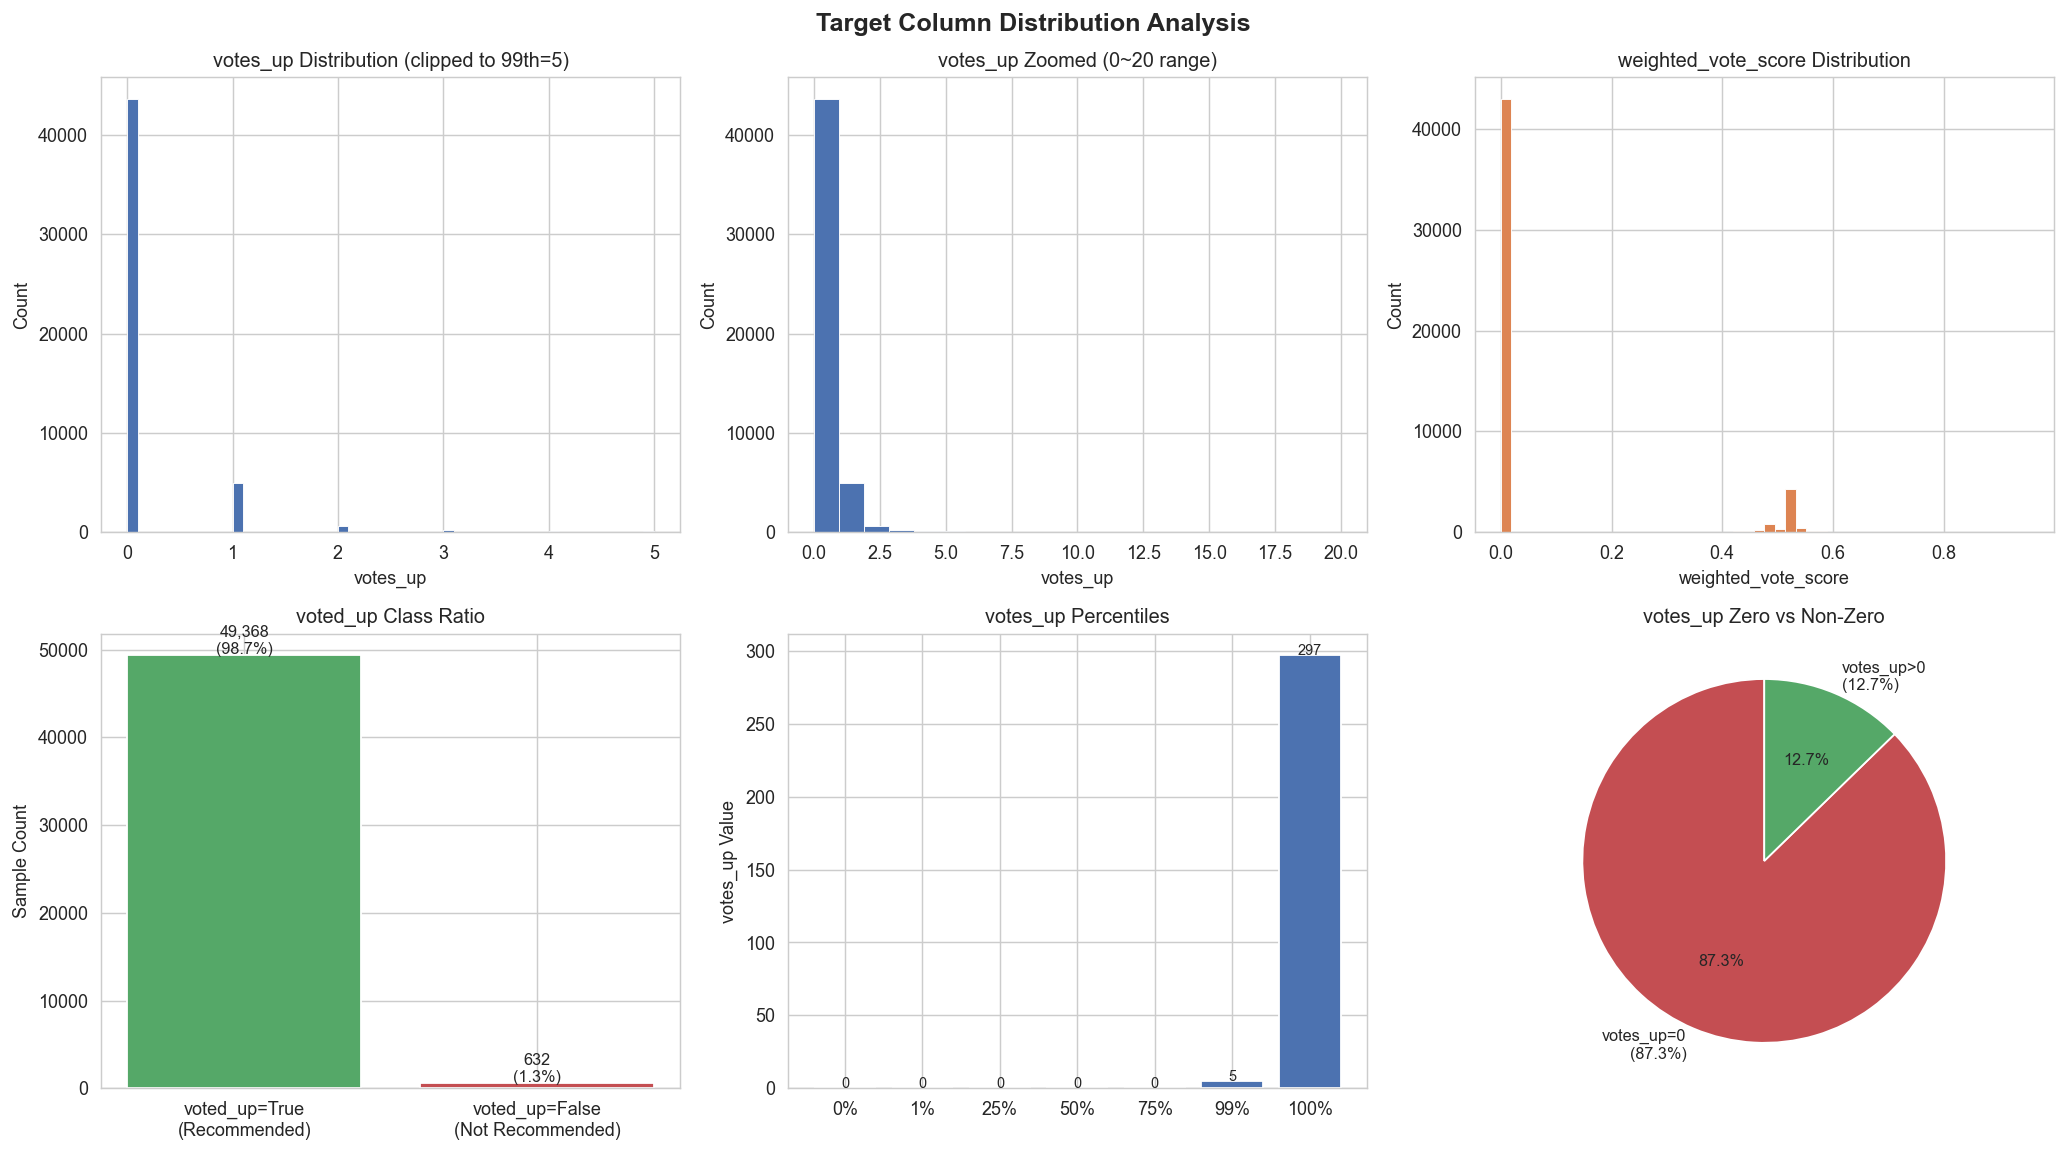

Saved: d:\Github_Desktop_File\ECE-9612-Group-Project\Image Printout\sec02_target_distribution.png
Target Column Stats Summary

[votes_up]
  mean=0.375  median=0  max=297
  skewness=36.60  kurtosis=1812.20
  zero ratio = 87.3%
  percentiles: p1=0  p50=0  p99=5  max=297

[weighted_vote_score]
  mean=0.0731  median=0.0000  range=[0.0000, 0.9520]
  skewness=2.14  zero ratio=86.0%

[voted_up]
  True  (Recommended)    : 49,368  (98.7%)
  False (Not Recommended): 632  (1.3%)
  pos/neg ratio = 78.11:1  WARNING: class imbalance!

[Decision]
  votes_up: heavily right-skewed (skewness >> 1), 87.3% zeros.
  Direct regression on raw values will perform poorly.
  => Use log1p(votes_up) as regression target, or convert to binary.
  weighted_vote_score: also mostly zeros (~86%), similar shape.
  voted_up: correlates with helpfulness but is not the same target.


In [54]:

# ============================================================
# Sec 2: Target Column Distribution Analysis
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Target Column Distribution Analysis", fontsize=14, fontweight="bold")

# (1) votes_up histogram (clipped to 99th pct)
ax = axes[0, 0]
p99_vu = df["votes_up"].quantile(0.99)
data_vu = df["votes_up"][df["votes_up"] <= p99_vu]
ax.hist(data_vu, bins=50, color="#4C72B0", edgecolor="white", linewidth=0.5)
ax.set_title(f"votes_up Distribution (clipped to 99th={p99_vu:.0f})")
ax.set_xlabel("votes_up"); ax.set_ylabel("Count")

# (2) votes_up zoomed (0-20)
ax = axes[0, 1]
ax.hist(df["votes_up"][df["votes_up"] <= 20], bins=21,
        color="#4C72B0", edgecolor="white", linewidth=0.5)
ax.set_title("votes_up Zoomed (0~20 range)")
ax.set_xlabel("votes_up"); ax.set_ylabel("Count")

# (3) weighted_vote_score histogram
ax = axes[0, 2]
ax.hist(df["weighted_vote_score"], bins=50, color="#DD8452", edgecolor="white", linewidth=0.5)
ax.set_title("weighted_vote_score Distribution")
ax.set_xlabel("weighted_vote_score"); ax.set_ylabel("Count")

# (4) voted_up class ratio
ax = axes[1, 0]
vc = df["voted_up"].value_counts()
ax.bar(["voted_up=True\n(Recommended)", "voted_up=False\n(Not Recommended)"],
       [vc.get(True, 0), vc.get(False, 0)],
       color=["#55A868", "#C44E52"], edgecolor="white")
ax.set_title("voted_up Class Ratio")
ax.set_ylabel("Sample Count")
for i, v in enumerate([vc.get(True, 0), vc.get(False, 0)]):
    ax.text(i, v + 100, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)

# (5) votes_up percentiles bar chart
ax = axes[1, 1]
pct_labels = ["0%", "1%", "25%", "50%", "75%", "99%", "100%"]
pct_vals   = [0, 0.01, 0.25, 0.50, 0.75, 0.99, 1.00]
pct_data   = [df["votes_up"].quantile(q) for q in pct_vals]
ax.bar(pct_labels, pct_data, color="#4C72B0", edgecolor="white")
ax.set_title("votes_up Percentiles")
ax.set_ylabel("votes_up Value")
for i, v in enumerate(pct_data):
    ax.text(i, v + 0.3, f"{v:.0f}", ha="center", fontsize=8)

# (6) votes_up zero vs non-zero
ax = axes[1, 2]
zero_n    = (df["votes_up"] == 0).sum()
nonzero_n = (df["votes_up"] > 0).sum()
ax.pie([zero_n, nonzero_n],
       labels=[f"votes_up=0\n({zero_n/len(df)*100:.1f}%)",
               f"votes_up>0\n({nonzero_n/len(df)*100:.1f}%)"],
       colors=["#C44E52","#55A868"], startangle=90,
       autopct="%1.1f%%", textprops={"fontsize": 9})
ax.set_title("votes_up Zero vs Non-Zero")

plt.tight_layout()
_save_path = os.path.join(IMG_DIR, "sec02_target_distribution.png")
plt.savefig(_save_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {_save_path}")

# Stats summary
print("=" * 65)
print("Target Column Stats Summary")
print("=" * 65)

print("\n[votes_up]")
vu = df["votes_up"]
print(f"  mean={vu.mean():.3f}  median={vu.median():.0f}  max={vu.max()}")
print(f"  skewness={vu.skew():.2f}  kurtosis={vu.kurt():.2f}")
print(f"  zero ratio = {(vu==0).mean()*100:.1f}%")
print(f"  percentiles: p1={vu.quantile(.01):.0f}  p50={vu.quantile(.5):.0f}  "
      f"p99={vu.quantile(.99):.0f}  max={vu.max()}")

print("\n[weighted_vote_score]")
wvs = df["weighted_vote_score"]
print(f"  mean={wvs.mean():.4f}  median={wvs.median():.4f}  range=[{wvs.min():.4f}, {wvs.max():.4f}]")
print(f"  skewness={wvs.skew():.2f}  zero ratio={(wvs==0).mean()*100:.1f}%")

print("\n[voted_up]")
vc = df["voted_up"].value_counts()
print(f"  True  (Recommended)    : {vc.get(True,0):,}  ({vc.get(True,0)/len(df)*100:.1f}%)")
print(f"  False (Not Recommended): {vc.get(False,0):,}  ({vc.get(False,0)/len(df)*100:.1f}%)")
ratio = vc.get(True,0) / max(vc.get(False,0), 1)
print(f"  pos/neg ratio = {ratio:.2f}:1  ", end="")
if ratio > 3:
    print("WARNING: class imbalance!")
else:
    print("OK: roughly balanced")

print()
print("=" * 65)
print("[Decision]")
print("  votes_up: heavily right-skewed (skewness >> 1), 87.3% zeros.")
print("  Direct regression on raw values will perform poorly.")
print("  => Use log1p(votes_up) as regression target, or convert to binary.")
print("  weighted_vote_score: also mostly zeros (~86%), similar shape.")
print("  voted_up: correlates with helpfulness but is not the same target.")
print("=" * 65)


---
## 第 3 节：Log 变换效果验证

> 🎯 **核心问题：log 变换能否拯救极度偏态的 votes_up？**
>
> `votes_up` 偏度极大，87% 为 0——这对线性模型是灾难，对树模型也是挑战。  
> `log1p(x) = log(x + 1)` 是处理计数型长尾分布的标准手段。  
>
> 本节用数据回答：变换后偏度是否明显改善，是否接近正态（偏度趋近 0）。  
> **这个结论直接决定 target 的处理方式和评估指标的选择。**


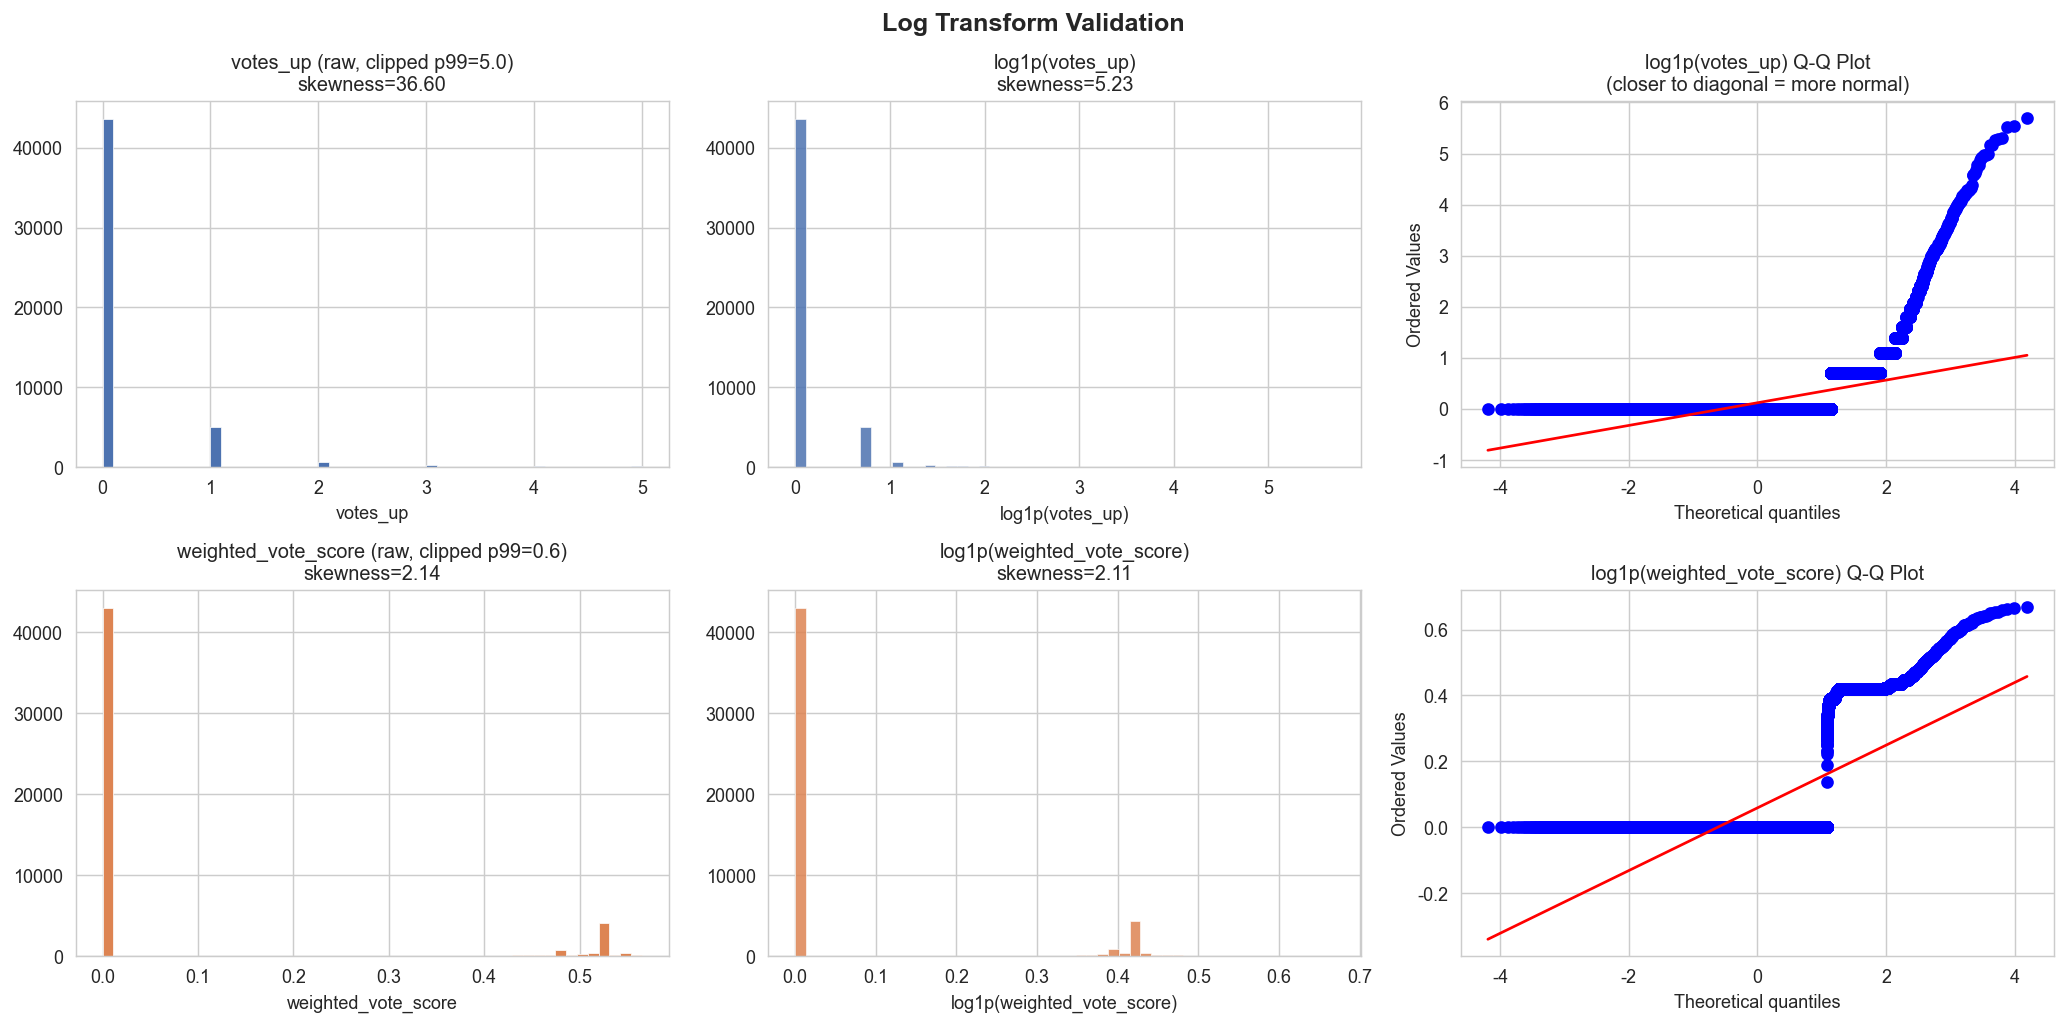

Saved: d:\Github_Desktop_File\ECE-9612-Group-Project\Image Printout\sec03_log_transform_validation.png
Log Transform Effect Comparison

  votes_up
    raw skewness   = +36.601
    log1p skewness = +5.227  => improved significantly

  weighted_vote_score
    raw skewness   = +2.139
    log1p skewness = +2.112  => improved significantly

-----------------------------------------------------------------
Binary classification threshold analysis:
  votes_up >= 1 : 12.7% positive samples
  votes_up >= 3 : 1.6% positive samples
  => class ratio with threshold=1: 13:87

[Decision]
  log1p(votes_up) skewness = 5.23. Still skewed.
  => Consider binary classification (votes_up >= 1 as positive).
     Positive ratio = 12.7%, handle class imbalance.


In [55]:

# ============================================================
# Sec 3: Log Transform Validation
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Log Transform Validation", fontsize=14, fontweight="bold")

def plot_transform_pair(ax_raw, ax_log, series, name, color):
    p99 = series.quantile(0.99)
    raw = series[series <= p99]
    log = np.log1p(series)
    ax_raw.hist(raw, bins=50, color=color, edgecolor="white", linewidth=0.4)
    ax_raw.set_title(f"{name} (raw, clipped p99={p99:.1f})\nskewness={series.skew():.2f}")
    ax_raw.set_xlabel(name)
    ax_log.hist(log, bins=50, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax_log.set_title(f"log1p({name})\nskewness={log.skew():.2f}")
    ax_log.set_xlabel(f"log1p({name})")

plot_transform_pair(axes[0,0], axes[0,1], df["votes_up"], "votes_up", "#4C72B0")
plot_transform_pair(axes[1,0], axes[1,1], df["weighted_vote_score"], "weighted_vote_score", "#DD8452")

# Q-Q plots to check normality after log1p
ax = axes[0, 2]
log_vu = np.log1p(df["votes_up"])
stats.probplot(log_vu, dist="norm", plot=ax)
ax.set_title("log1p(votes_up) Q-Q Plot\n(closer to diagonal = more normal)")

ax = axes[1, 2]
log_wvs = np.log1p(df["weighted_vote_score"])
stats.probplot(log_wvs, dist="norm", plot=ax)
ax.set_title("log1p(weighted_vote_score) Q-Q Plot")

plt.tight_layout()
_save_path = os.path.join(IMG_DIR, "sec03_log_transform_validation.png")
plt.savefig(_save_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {_save_path}")

print("=" * 65)
print("Log Transform Effect Comparison")
print("=" * 65)

results = []
for col, label in [("votes_up", "votes_up"),
                   ("weighted_vote_score", "weighted_vote_score")]:
    raw_skew = df[col].skew()
    log_skew = np.log1p(df[col]).skew()
    improved = abs(log_skew) < abs(raw_skew)
    results.append((label, raw_skew, log_skew, improved))
    print(f"\n  {label}")
    print(f"    raw skewness   = {raw_skew:+.3f}")
    print(f"    log1p skewness = {log_skew:+.3f}  {'=> improved significantly' if improved else '=> limited improvement'}")

threshold_1 = (df["votes_up"] >= 1).mean() * 100
threshold_3 = (df["votes_up"] >= 3).mean() * 100
print()
print("-" * 65)
print("Binary classification threshold analysis:")
print(f"  votes_up >= 1 : {threshold_1:.1f}% positive samples")
print(f"  votes_up >= 3 : {threshold_3:.1f}% positive samples")
print(f"  => class ratio with threshold=1: {threshold_1:.0f}:{100-threshold_1:.0f}")

print()
print("=" * 65)
print("[Decision]")
log_vu_skew = np.log1p(df["votes_up"]).skew()
if abs(log_vu_skew) < 1.0:
    print(f"  log1p(votes_up) skewness = {log_vu_skew:.2f} (near 0). Transform is effective.")
    print("  => Use log1p(votes_up) as regression target, then expm1 to recover predictions.")
    print("  => Evaluate MAE/RMSE on original scale after inverse transform.")
else:
    print(f"  log1p(votes_up) skewness = {log_vu_skew:.2f}. Still skewed.")
    print("  => Consider binary classification (votes_up >= 1 as positive).")
    print(f"     Positive ratio = {threshold_1:.1f}%, handle class imbalance.")
print("=" * 65)


---
## 第 4 节：文本特征初步分析

> 🎯 **核心问题：review 列值不值得做 NLP？**
>
> 从 `Understand_csv` 已知：
> - `review` 列平均长度 **85 字符**，中位数仅 **29 字符**，标准差高达 **227 字符**  
> - 最短 1 字符，最长 7999 字符——分布极不均匀  
> - 语言多样：共 **28 种语言**
>
> 本节重点回答：
> 1. 文本长度本身是否与 helpfulness 相关（是否值得用作特征）
> 2. 是否值得做 NLP（需先确认英文评论的比例和质量）
> 3. 有多少评论太短，不适合 NLP 处理


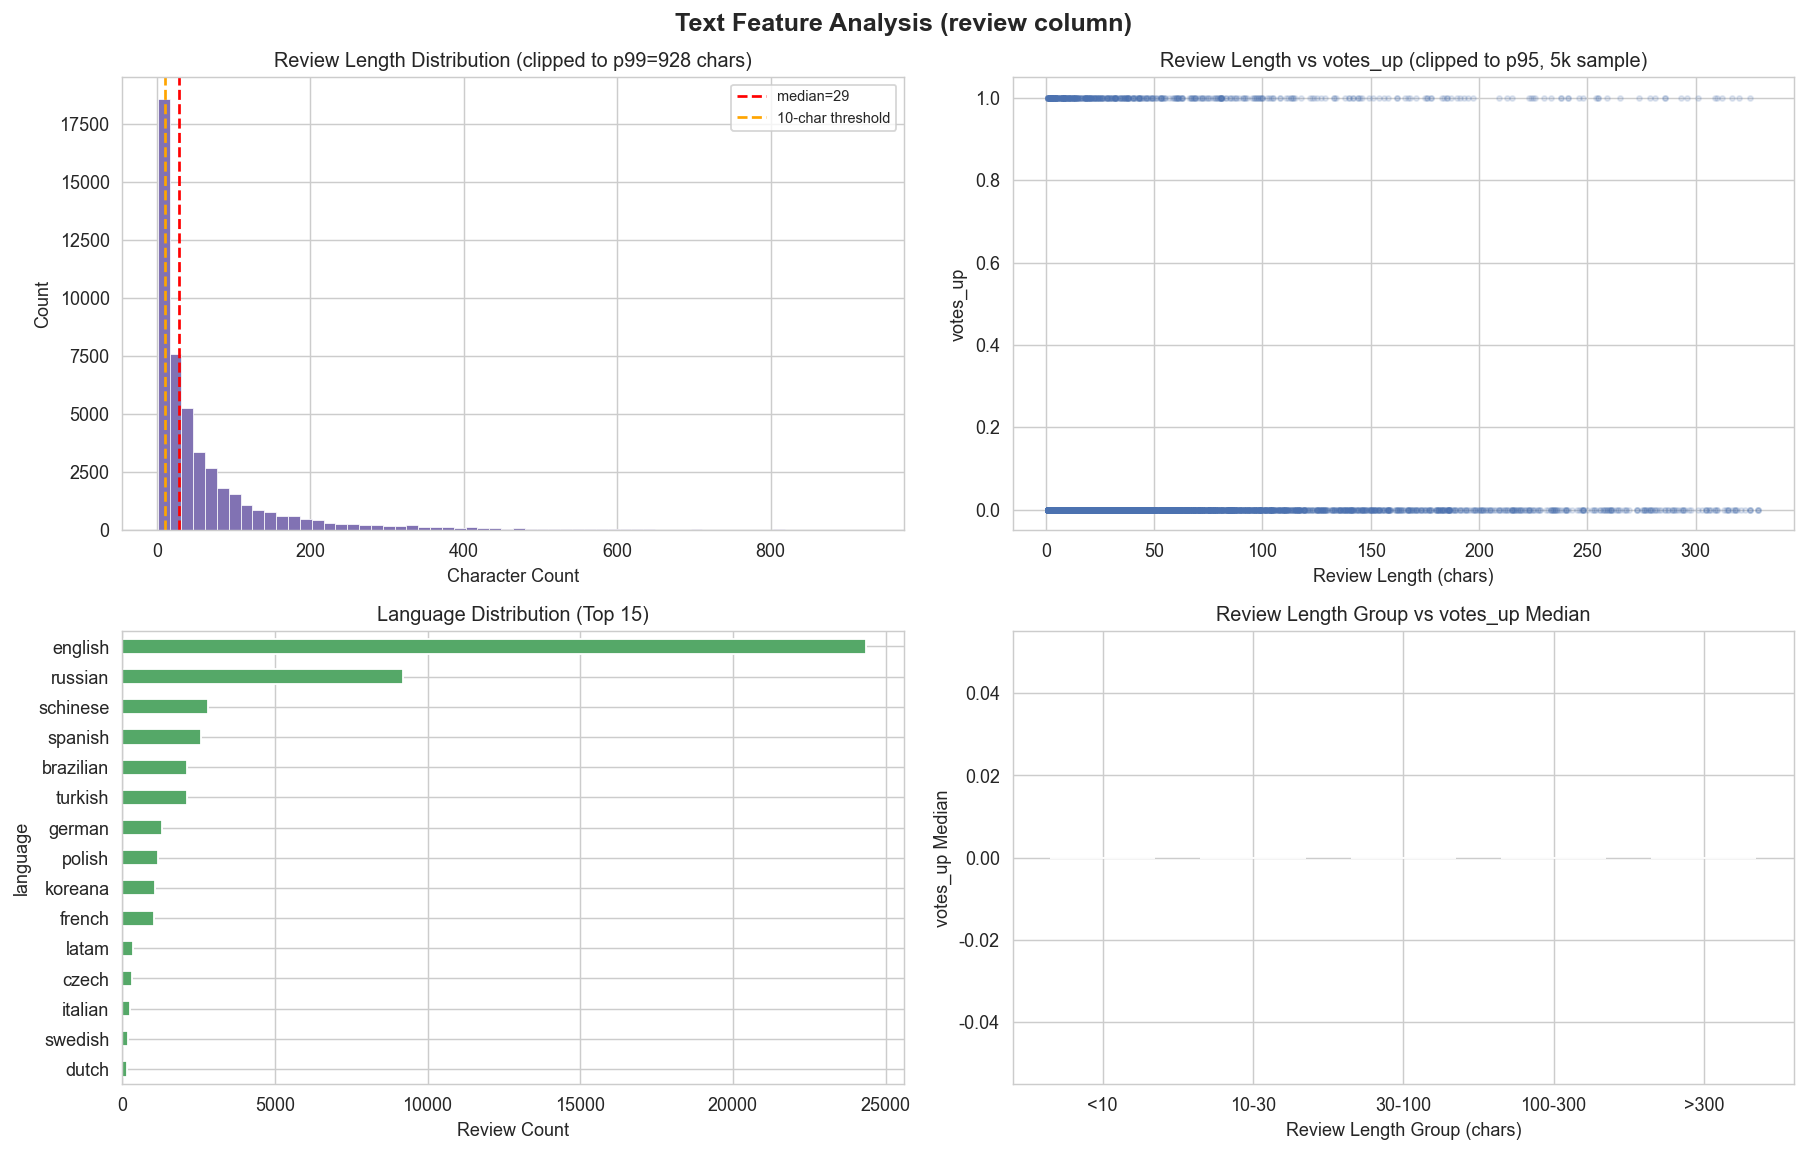

Saved: d:\Github_Desktop_File\ECE-9612-Group-Project\Image Printout\sec04_text_feature_analysis.png
Text Feature Stats Summary
  Valid reviews (non-null): 49,813 / 50,000 (99.6%)
  Very short (<10 chars):   12,267 (24.6%)
  Length percentiles: p1=1  p25=10  p50=29  p75=78  p99=928

  English review ratio: 48.8%
  Non-English ratio:    51.2% (28 languages total)

  Review length vs votes_up  Spearman r = 0.0911  p = 2.30e-92

[Decision]
  review_len has weak correlation with votes_up (r=0.091).
  => Feature value is limited; NLP content features would be more useful.
  English ratio = 48.8%. Multilingual — filter to English before NLP.


In [56]:

# ============================================================
# Sec 4: Text Feature Analysis
# ============================================================

df_text = df.dropna(subset=["review"]).copy()
df_text["review_len"] = df_text["review"].astype(str).str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Text Feature Analysis (review column)", fontsize=14, fontweight="bold")

# (1) Review length distribution
ax = axes[0, 0]
p99_len = df_text["review_len"].quantile(0.99)
ax.hist(df_text["review_len"][df_text["review_len"] <= p99_len],
        bins=60, color="#8172B3", edgecolor="white", linewidth=0.4)
ax.axvline(df_text["review_len"].median(), color="red", linestyle="--",
           linewidth=1.5, label=f"median={df_text['review_len'].median():.0f}")
ax.axvline(10, color="orange", linestyle="--", linewidth=1.5, label="10-char threshold")
ax.set_title(f"Review Length Distribution (clipped to p99={p99_len:.0f} chars)")
ax.set_xlabel("Character Count"); ax.set_ylabel("Count"); ax.legend(fontsize=8)

# (2) Review length vs votes_up scatter (5k sample)
ax = axes[0, 1]
sample_for_scatter = df_text.sample(min(5000, len(df_text)), random_state=42)
p95_len2 = sample_for_scatter["review_len"].quantile(0.95)
p95_vu   = sample_for_scatter["votes_up"].quantile(0.95)
mask = (sample_for_scatter["review_len"] <= p95_len2) & \
       (sample_for_scatter["votes_up"]   <= p95_vu)
ax.scatter(sample_for_scatter.loc[mask, "review_len"],
           sample_for_scatter.loc[mask, "votes_up"],
           alpha=0.15, s=8, color="#4C72B0")
ax.set_title("Review Length vs votes_up (clipped to p95, 5k sample)")
ax.set_xlabel("Review Length (chars)"); ax.set_ylabel("votes_up")

# (3) Language distribution
ax = axes[1, 0]
lang_counts = df["language"].value_counts().head(15)
lang_counts.plot(kind="barh", ax=ax, color="#55A868", edgecolor="white")
ax.set_title("Language Distribution (Top 15)")
ax.set_xlabel("Review Count"); ax.invert_yaxis()

# (4) Review length groups vs votes_up median
ax = axes[1, 1]
bins = [0, 10, 30, 100, 300, float("inf")]
labels_b = ["<10", "10-30", "30-100", "100-300", ">300"]
df_text["len_group"] = pd.cut(df_text["review_len"], bins=bins, labels=labels_b)
group_median = df_text.groupby("len_group", observed=True)["votes_up"].median()
group_median.plot(kind="bar", ax=ax, color="#DD8452", edgecolor="white", width=0.7)
ax.set_title("Review Length Group vs votes_up Median")
ax.set_xlabel("Review Length Group (chars)"); ax.set_ylabel("votes_up Median")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
_save_path = os.path.join(IMG_DIR, "sec04_text_feature_analysis.png")
plt.savefig(_save_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {_save_path}")

print("=" * 65)
print("Text Feature Stats Summary")
print("=" * 65)
print(f"  Valid reviews (non-null): {len(df_text):,} / {len(df):,} ({len(df_text)/len(df)*100:.1f}%)")
print(f"  Very short (<10 chars):   {(df_text['review_len'] < 10).sum():,} "
      f"({(df_text['review_len'] < 10).mean()*100:.1f}%)")
print(f"  Length percentiles: "
      f"p1={df_text['review_len'].quantile(.01):.0f}  "
      f"p25={df_text['review_len'].quantile(.25):.0f}  "
      f"p50={df_text['review_len'].quantile(.5):.0f}  "
      f"p75={df_text['review_len'].quantile(.75):.0f}  "
      f"p99={df_text['review_len'].quantile(.99):.0f}")

english_pct = (df["language"] == "english").mean() * 100
print(f"\n  English review ratio: {english_pct:.1f}%")
print(f"  Non-English ratio:    {100-english_pct:.1f}% ({df['language'].nunique()} languages total)")

r, p = stats.spearmanr(df_text["review_len"], df_text["votes_up"])
print(f"\n  Review length vs votes_up  Spearman r = {r:.4f}  p = {p:.2e}")

print()
print("=" * 65)
print("[Decision]")
if abs(r) > 0.1:
    print(f"  review_len has statistically significant correlation with votes_up (r={r:.3f}).")
    print("  => review_len (char count) is a useful feature; more stable than raw text.")
else:
    print(f"  review_len has weak correlation with votes_up (r={r:.3f}).")
    print("  => Feature value is limited; NLP content features would be more useful.")
if english_pct >= 70:
    print(f"  English reviews = {english_pct:.1f}%. Recommend filtering to English only for TF-IDF/BERT.")
else:
    print(f"  English ratio = {english_pct:.1f}%. Multilingual — filter to English before NLP.")
print("=" * 65)


---
## 第 5 节：数值特征分布与偏态检验

> 🎯 **核心问题：哪些数值特征需要 log 变换才能用好？**
>
> 从 `Understand_csv` 已知：游戏时长列（playtime）的最大值极端大：  
> - `playtime_forever` 最大值 = **1,942,435 分钟**（≈ 3235 小时）  
> - `playtime_at_review` 最大值 = **1,751,059 分钟**（≈ 2918 小时）  
>
> 这样的长尾分布会严重拖累线性模型，对树模型的影响相对小但仍存在。  
> **本节批量检验每个数值特征的偏态，输出"是否建议 log 变换"的结论表。**


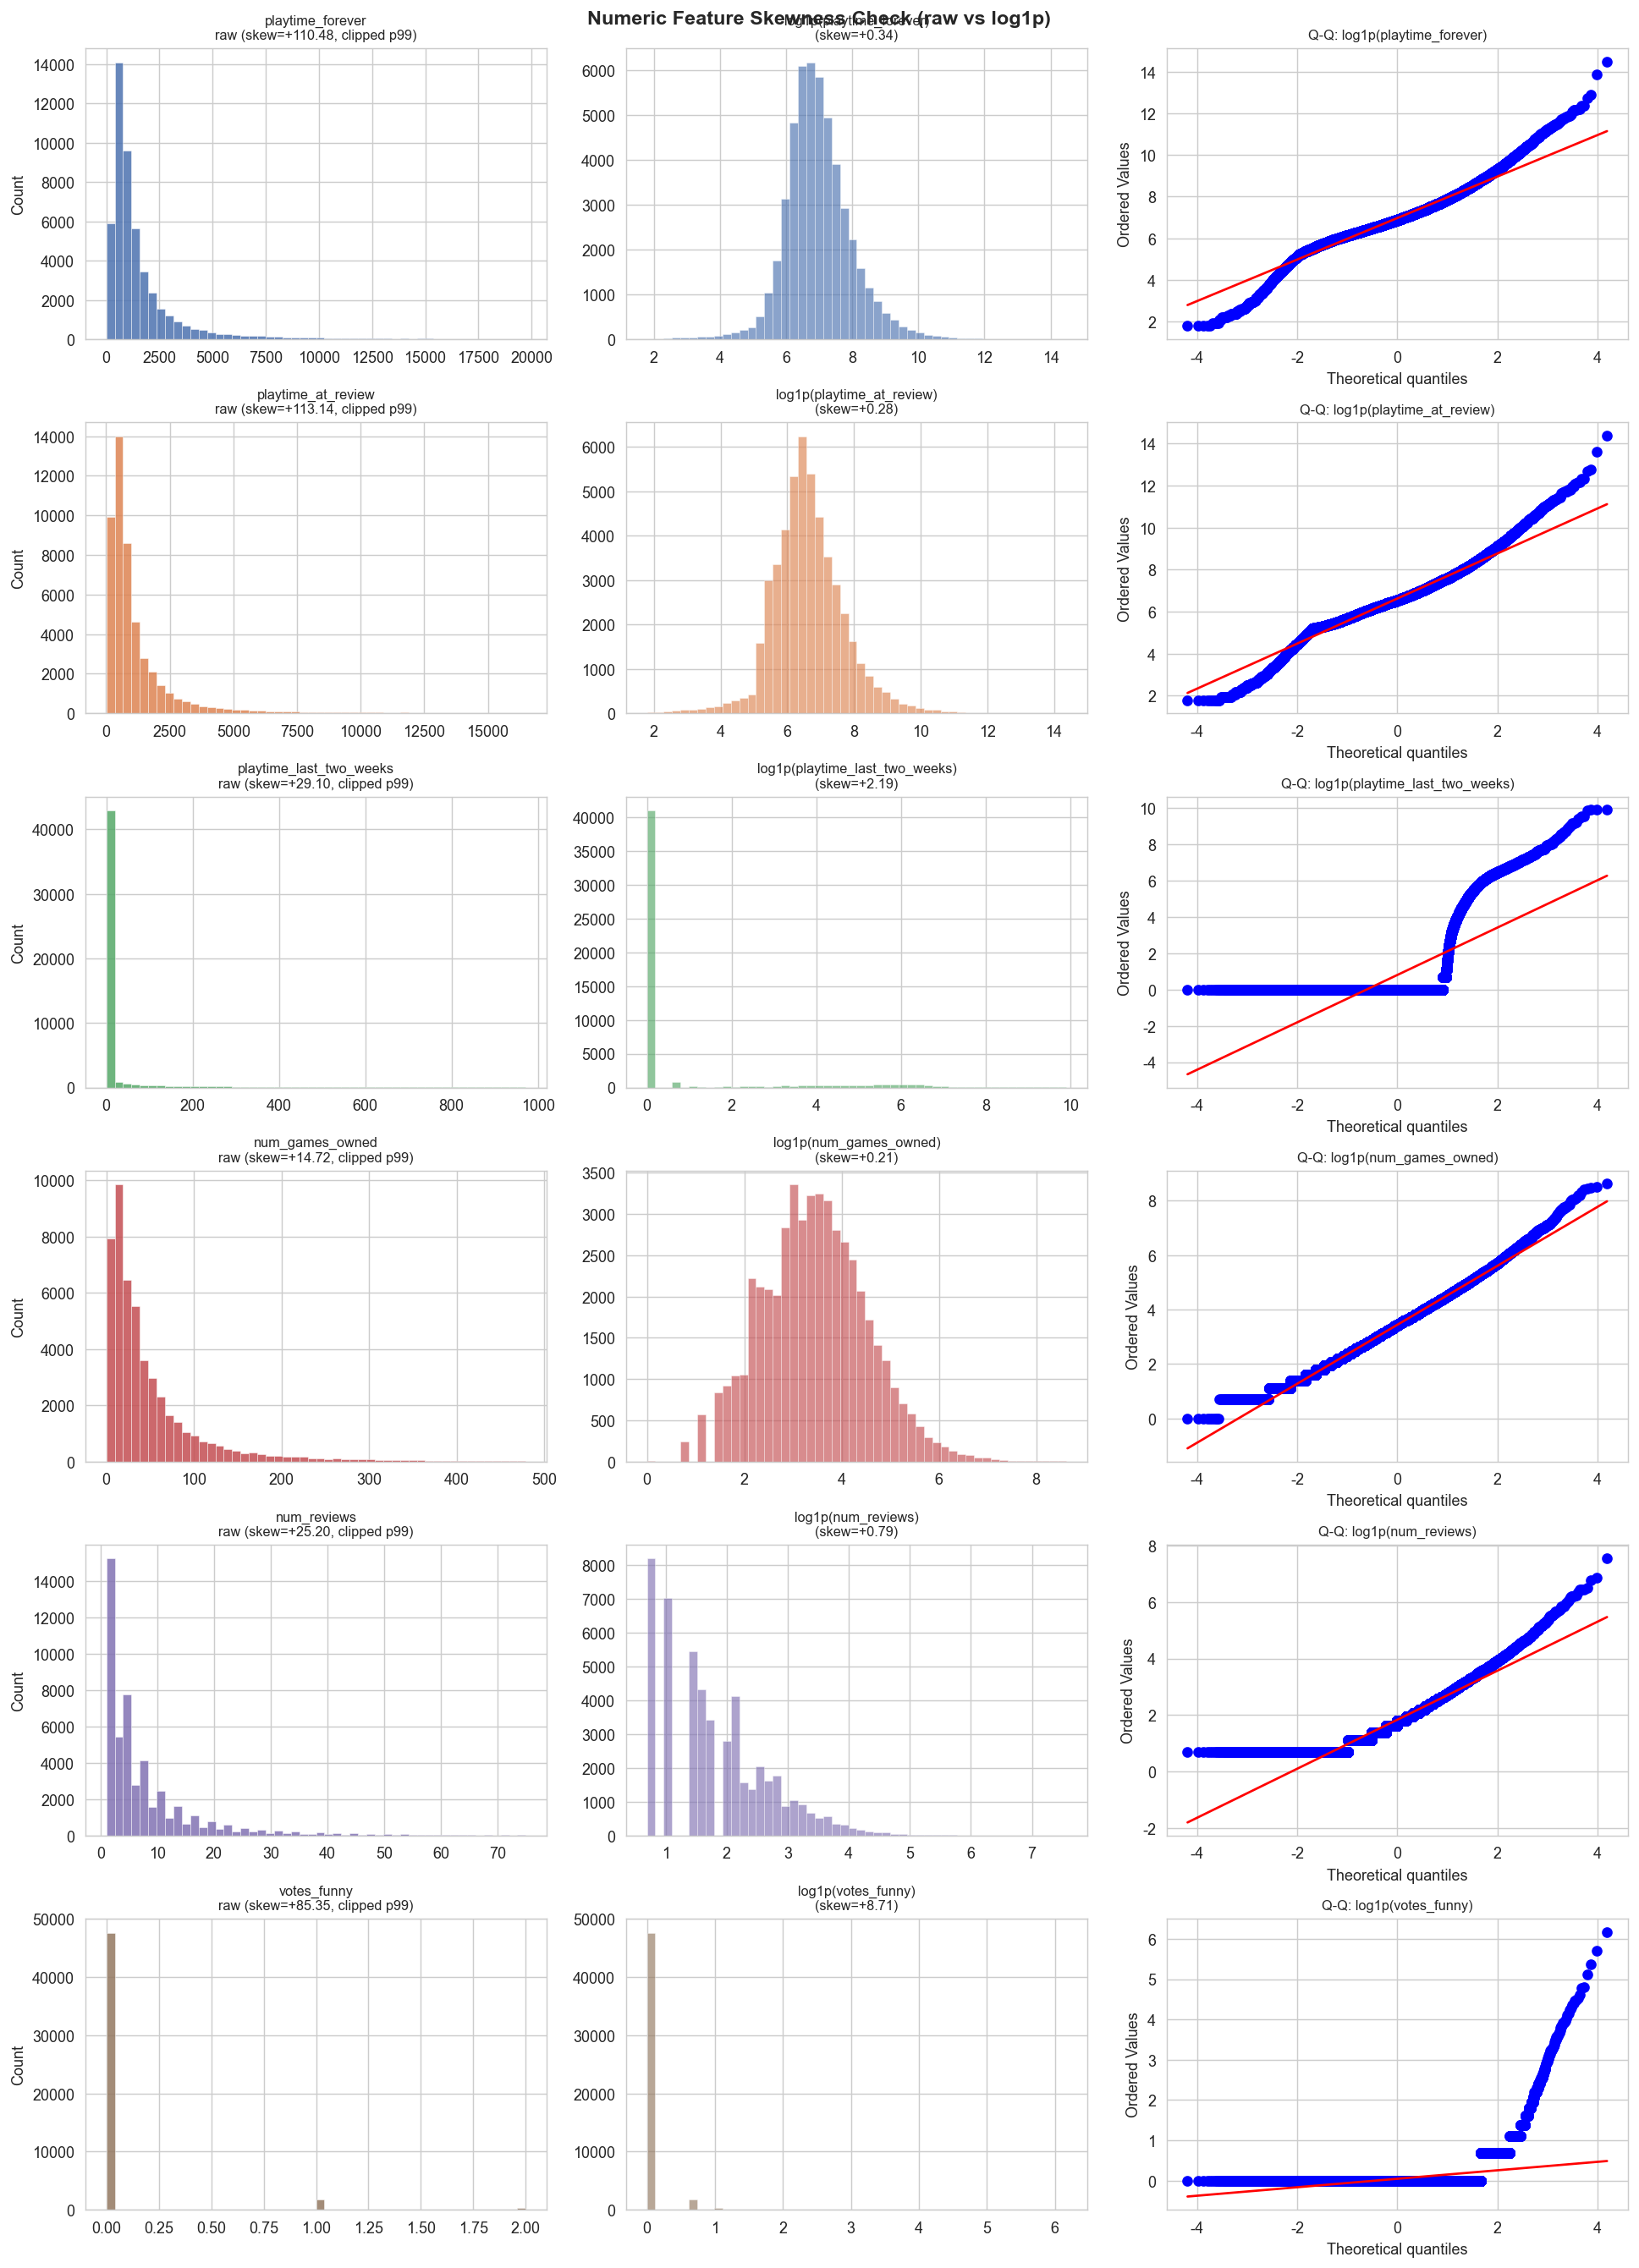

Saved: d:\Github_Desktop_File\ECE-9612-Group-Project\Image Printout\sec05_numeric_skewness_check.png
Numeric Feature Skewness Summary (log transform recommendation)
                Feature Raw Skewness log1p Skewness Zero %  Recommend log
       playtime_forever      +110.48          +0.34     0.0           Yes
     playtime_at_review      +113.14          +0.28     0.0           Yes
playtime_last_two_weeks       +29.10          +2.19    82.0           Yes
        num_games_owned       +14.72          +0.21     0.0           Yes
            num_reviews       +25.20          +0.79     0.0           Yes
            votes_funny       +85.35          +8.71    95.3           Yes

[Decision]
  |skew| > 1 AND log1p improves it  => apply log1p transform
  |skew| < 1 OR log1p shows no gain => keep raw value

  Extreme values will heavily bias linear models. Always apply log1p.
  Tree models (LightGBM) are more tolerant but log1p still recommended.


In [57]:

# ============================================================
# Sec 5: Numeric Feature Skewness Check
# ============================================================

NUMERIC_FEATS = ["playtime_forever", "playtime_at_review",
                 "playtime_last_two_weeks", "num_games_owned",
                 "num_reviews", "votes_funny"]

n_cols = 3
n_rows = len(NUMERIC_FEATS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows))
fig.suptitle("Numeric Feature Skewness Check (raw vs log1p)", fontsize=13, fontweight="bold")

skew_table = []
colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860"]

for i, feat in enumerate(NUMERIC_FEATS):
    if feat not in df.columns:
        skew_table.append({"Feature": feat, "Raw Skew": "N/A",
                           "log1p Skew": "N/A", "Recommend log": "No (missing)"})
        continue

    series   = df[feat].dropna()
    log_s    = np.log1p(series)
    raw_skew = series.skew()
    log_skew = log_s.skew()
    zero_pct = (series == 0).mean() * 100
    p99      = series.quantile(0.99)
    need_log = abs(log_skew) < abs(raw_skew) and abs(raw_skew) > 1.0

    skew_table.append({
        "Feature":       feat,
        "Raw Skewness":  f"{raw_skew:+.2f}",
        "log1p Skewness":f"{log_skew:+.2f}",
        "Zero % ":       f"{zero_pct:.1f}",
        "Recommend log": "Yes" if need_log else "No"
    })

    color = colors[i % len(colors)]

    # Raw distribution (clipped to p99)
    ax = axes[i, 0]
    raw_plot = series[series <= p99]
    ax.hist(raw_plot, bins=50, color=color, edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.set_title(f"{feat}\nraw (skew={raw_skew:+.2f}, clipped p99)", fontsize=9)
    ax.set_ylabel("Count")

    # log1p distribution
    ax = axes[i, 1]
    ax.hist(log_s, bins=50, color=color, edgecolor="white", linewidth=0.3, alpha=0.65)
    ax.set_title(f"log1p({feat})\n(skew={log_skew:+.2f})", fontsize=9)

    # Q-Q plot (log1p)
    ax = axes[i, 2]
    stats.probplot(log_s, dist="norm", plot=ax)
    ax.set_title(f"Q-Q: log1p({feat})", fontsize=9)

plt.tight_layout()
_save_path = os.path.join(IMG_DIR, "sec05_numeric_skewness_check.png")
plt.savefig(_save_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {_save_path}")

print("=" * 70)
print("Numeric Feature Skewness Summary (log transform recommendation)")
print("=" * 70)
skew_df = pd.DataFrame(skew_table)
print(skew_df.to_string(index=False))

print()
print("=" * 70)
print("[Decision]")
print("  |skew| > 1 AND log1p improves it  => apply log1p transform")
print("  |skew| < 1 OR log1p shows no gain => keep raw value")
print()
print("  WARNING: playtime_forever and playtime_at_review have max > 1e6 min.")
print("  Extreme values will heavily bias linear models. Always apply log1p.")
print("  Tree models (LightGBM) are more tolerant but log1p still recommended.")
print("=" * 70)


---
## 第 6 节：类别特征与 Target 的关系分析

> 🎯 **核心问题：哪些类别特征对 helpfulness 有实质影响？**
>
> 本数据集有以下类别/布尔特征：
> - `language`（28种语言）：**不同语言的评论长度、质量差异很大**
> - `steam_purchase`（是否 Steam 正版购买）：**非正版用户评论可信度问题**
> - `received_for_free`（是否免费获得）：**免费赠品的评论可能有刷票嫌疑**
> - `written_during_early_access`（抢先体验期）：**该期间评论可能不成熟**
>
> 本节用分组分析找出**对 votes_up 有显著影响的类别特征**，指导特征编码策略。


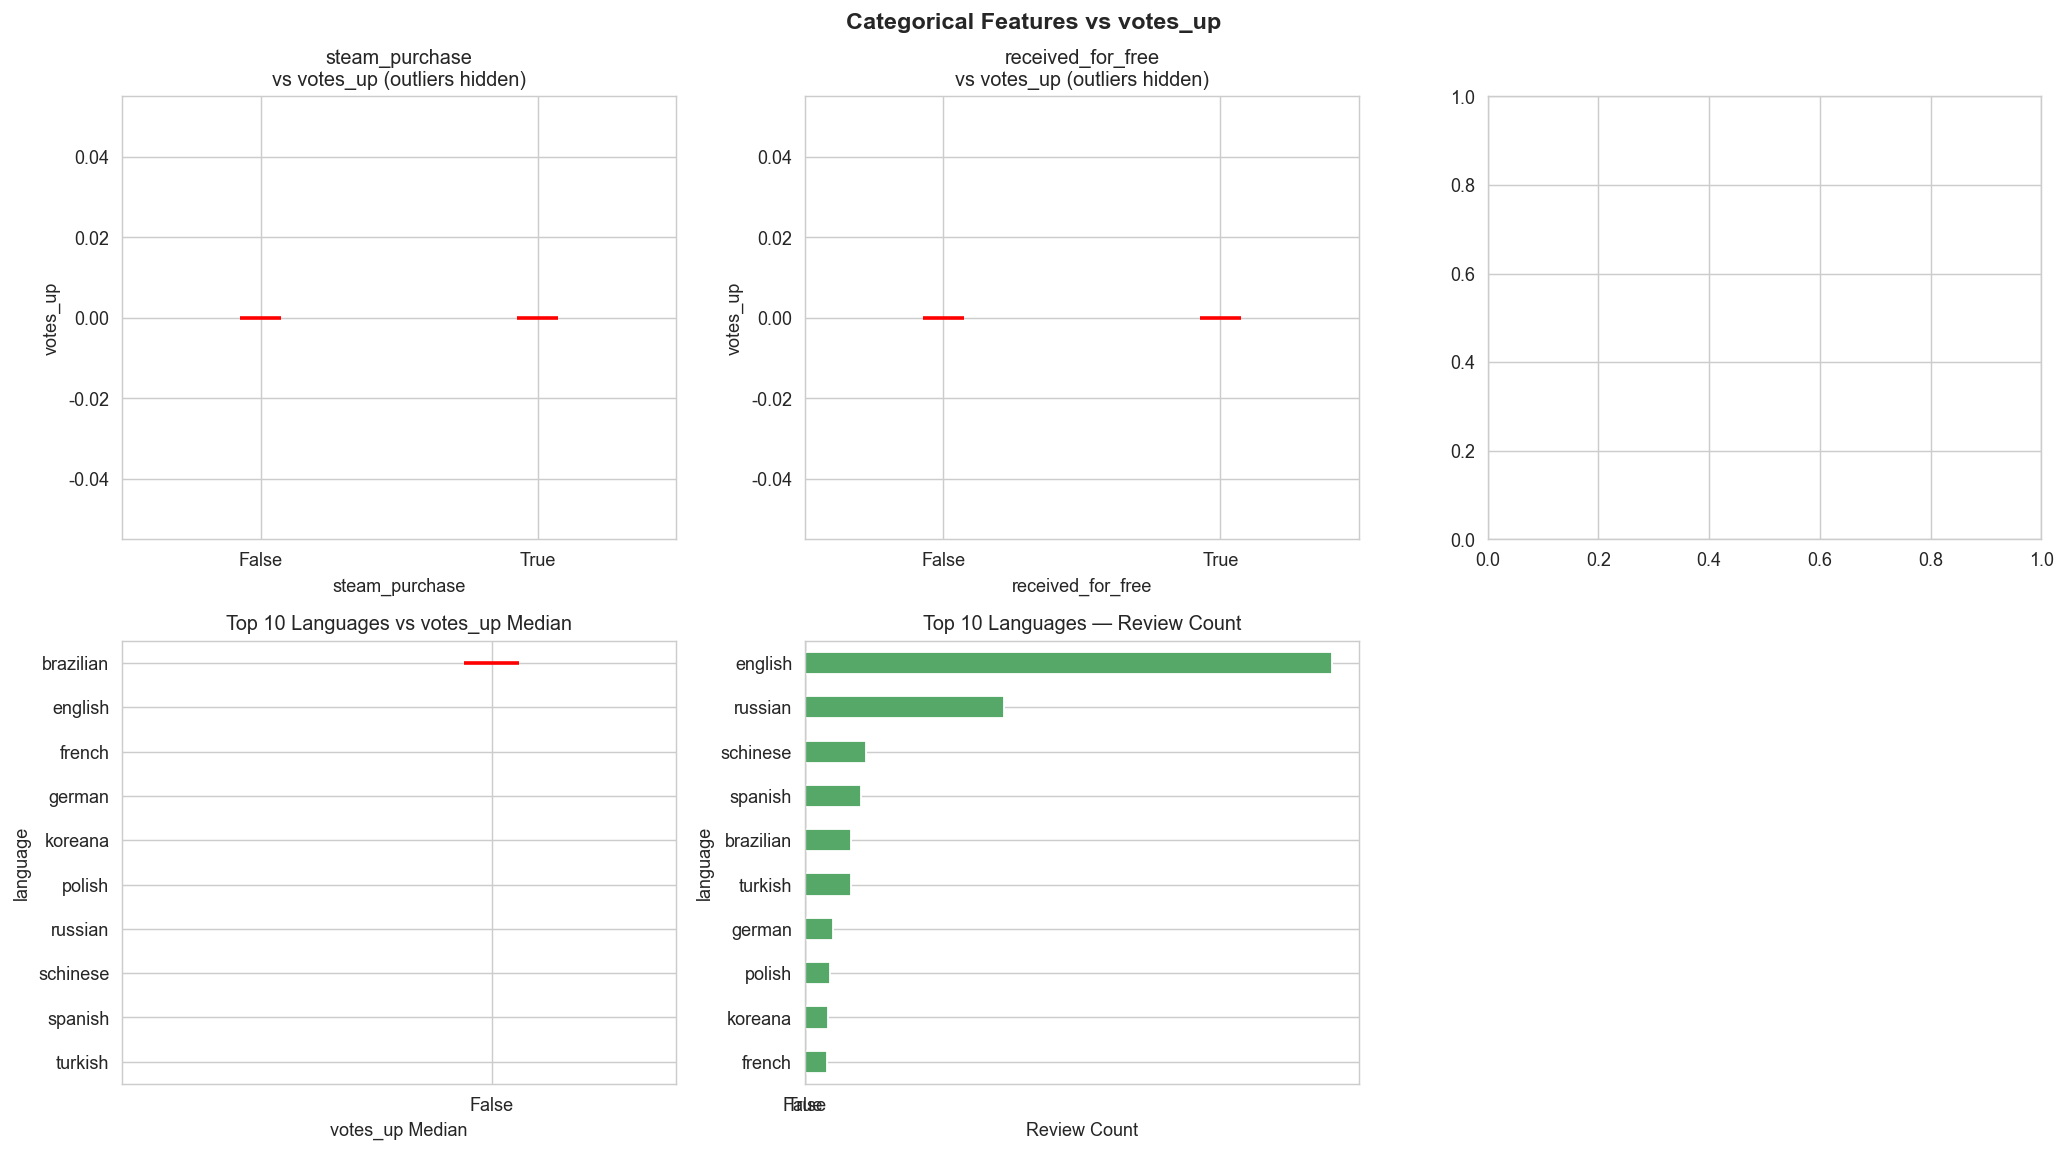

Saved: d:\Github_Desktop_File\ECE-9612-Group-Project\Image Printout\sec06_categorical_vs_target.png
Categorical Feature Group Stats: votes_up mean / median / count

  [steam_purchase]
                 Mean  Median  Count
steam_purchase                      
False          0.3890  0.0000   6863
True           0.3724  0.0000  43137

  [received_for_free]
                    Mean  Median  Count
received_for_free                      
False             0.3766  0.0000  48504
True              0.3128  0.0000   1496

  [written_during_early_access]
                              Mean  Median  Count
written_during_early_access                      
False                       0.3747  0.0000  50000

  [voted_up]
           Mean  Median  Count
voted_up                      
False    1.2943  0.0000    632
True     0.3629  0.0000  49368

[Decision]
  steam_purchase / received_for_free / written_during_early_access:
    Boolean -> encode as 0/1 directly, no special handling needed.
  language: 28 la

In [58]:

# ============================================================
# Sec 6: Categorical Features vs Target Analysis
# ============================================================

CAT_FEATS = ["steam_purchase", "received_for_free",
             "written_during_early_access", "voted_up"]
TARGET    = "votes_up"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Categorical Features vs votes_up", fontsize=13, fontweight="bold")

# Boolean features boxplots
for idx, feat in enumerate(CAT_FEATS):
    if feat not in df.columns:
        continue
    ax = axes[idx // 2, idx % 2]
    groups = df.groupby(df[feat].astype(str))[TARGET].apply(list)
    bp = ax.boxplot(groups.values, labels=groups.index,
                    patch_artist=True, showfliers=False,
                    medianprops={"color":"red","linewidth":2})
    colors_bp = ["#4C72B0", "#DD8452"]
    for patch, color in zip(bp["boxes"], colors_bp):
        patch.set_facecolor(color)
    ax.set_title(f"{feat}\nvs votes_up (outliers hidden)")
    ax.set_ylabel("votes_up")
    ax.set_xlabel(feat)

# Language Top10 vs votes_up median
ax = axes[1, 0]
top_langs = df["language"].value_counts().head(10).index
lang_med  = df[df["language"].isin(top_langs)].groupby("language")[TARGET].median().sort_values()
lang_med.plot(kind="barh", ax=ax, color="#8172B3", edgecolor="white")
ax.set_title("Top 10 Languages vs votes_up Median")
ax.set_xlabel("votes_up Median"); ax.invert_yaxis()

# Language Top10 review count
ax = axes[1, 1]
top_lang_cnt = df["language"].value_counts().head(10)
top_lang_cnt.plot(kind="barh", ax=ax, color="#55A868", edgecolor="white")
ax.set_title("Top 10 Languages — Review Count")
ax.set_xlabel("Review Count"); ax.invert_yaxis()

axes[1, 2].axis("off")

plt.tight_layout()
_save_path = os.path.join(IMG_DIR, "sec06_categorical_vs_target.png")
plt.savefig(_save_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {_save_path}")

print("=" * 70)
print("Categorical Feature Group Stats: votes_up mean / median / count")
print("=" * 70)
for feat in CAT_FEATS:
    if feat not in df.columns:
        continue
    grp = df.groupby(df[feat].astype(str))[TARGET].agg(["mean","median","count"])
    grp.columns = ["Mean", "Median", "Count"]
    print(f"\n  [{feat}]")
    print(grp.to_string())

print()
print("=" * 70)
print("[Decision]")
print("  steam_purchase / received_for_free / written_during_early_access:")
print("    Boolean -> encode as 0/1 directly, no special handling needed.")
print("  language: 28 languages. If English-only model, just filter and drop.")
print("    For multilingual, use target encoding (replace label with mean votes_up).")
print("  voted_up (as a feature): correlated with votes_up but use with caution.")
print("    Do not use as both feature and target simultaneously.")
print("=" * 70)


---
## 第 7 节：用户行为特征探索

> 🎯 **核心问题：playtime / num_games_owned / num_reviews 与 helpfulness 相关吗？**
>
> 直觉上：
> - **玩了更长时间**的用户（`playtime_forever` 大）写的评论可能更有深度 → votes 更高
> - **写过更多评论**的用户（`num_reviews` 大）可能是活跃用户，但也可能是刷评论者
> - **拥有更多游戏**的用户（`num_games_owned` 大）是平台老用户，评论质量可能更高
>
> 但这些都只是直觉，**本节用 Spearman 相关系数验证**（因数据非正态，Pearson 不适用）。


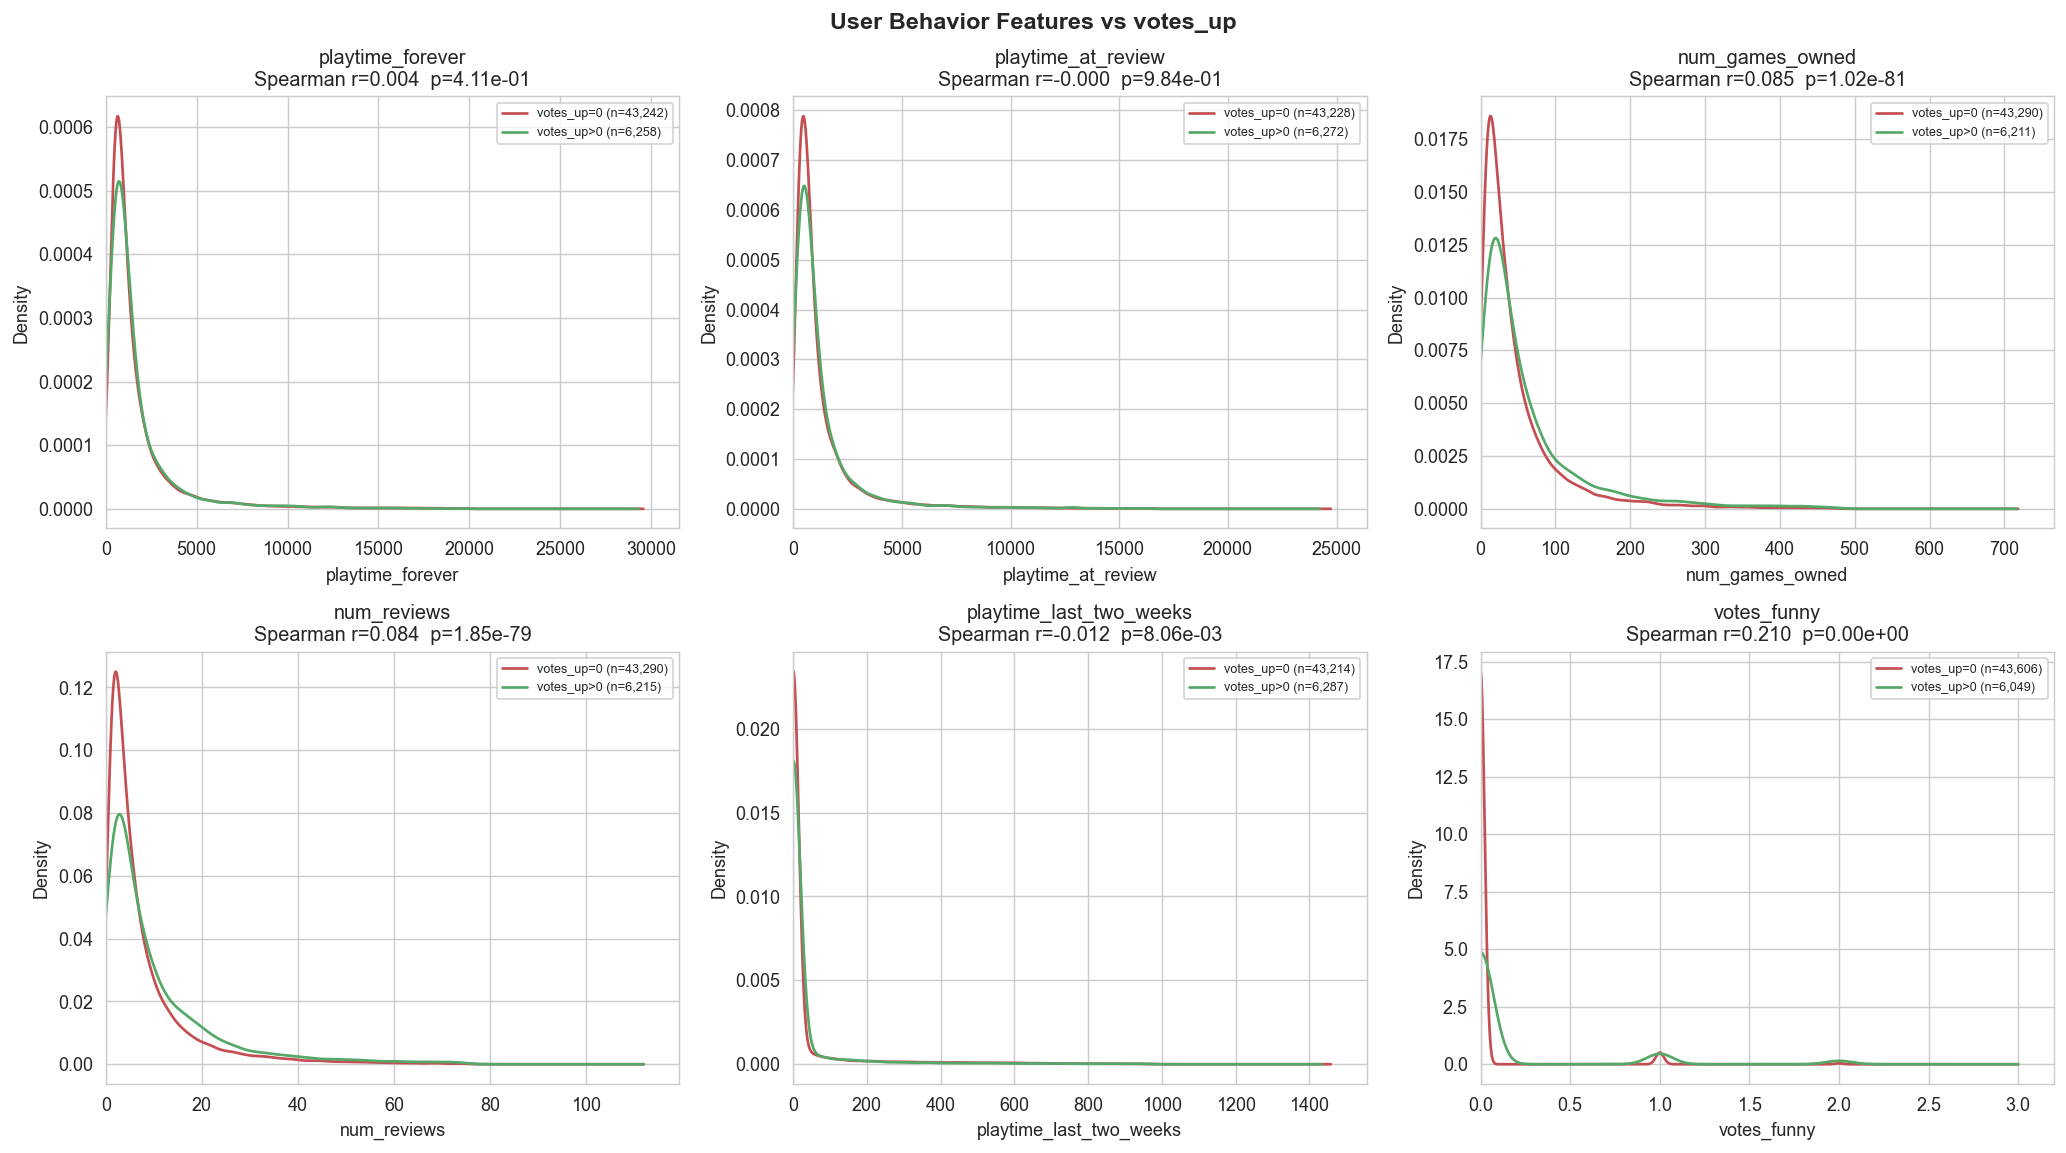

Saved: d:\Github_Desktop_File\ECE-9612-Group-Project\Image Printout\sec07_user_behavior_spearman_kde.png
User Behavior Features vs votes_up  Spearman Correlation
                Feature  Spearman r  p-value Significant Strength
       playtime_forever      0.0037 4.11e-01          No     Weak
     playtime_at_review     -0.0001 9.84e-01          No     Weak
        num_games_owned      0.0855 1.02e-81         Yes     Weak
            num_reviews      0.0843 1.85e-79         Yes     Weak
playtime_last_two_weeks     -0.0118 8.06e-03         Yes     Weak
            votes_funny      0.2100 0.00e+00         Yes   Strong

[Decision]
  |r| > 0.2  => Strong correlation, keep this feature
  |r| 0.1-0.2 => Medium, keep but do not rely on it alone
  |r| < 0.1  => Weak/none, consider dropping

  NOTE: Spearman only captures monotone relationships.
  Tree models can exploit nonlinear patterns, so even low-r
  features may still contribute to tree-based models.


In [59]:

# ============================================================
# Sec 7: User Behavior Feature Exploration
# ============================================================

USER_FEATS = ["playtime_forever", "playtime_at_review",
              "num_games_owned", "num_reviews",
              "playtime_last_two_weeks", "votes_funny"]
TARGET     = "votes_up"

available = [f for f in USER_FEATS if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("User Behavior Features vs votes_up", fontsize=13, fontweight="bold")

spearman_rows = []
colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860"]

for i, feat in enumerate(available):
    ax = axes[i // 3, i % 3]

    r, p = stats.spearmanr(df[feat].dropna(), df.loc[df[feat].notna(), TARGET])
    spearman_rows.append({
        "Feature":   feat,
        "Spearman r": round(r, 4),
        "p-value":    f"{p:.2e}",
        "Significant": "Yes" if p < 0.05 else "No",
        "Strength":    "Strong" if abs(r) > 0.2 else ("Medium" if abs(r) > 0.1 else "Weak")
    })

    # KDE: votes_up=0 group vs votes_up>0 group
    g0 = df.loc[df[TARGET] == 0, feat].dropna()
    g1 = df.loc[df[TARGET] > 0,  feat].dropna()
    p99_f = df[feat].quantile(0.99)
    g0_c  = g0[g0 <= p99_f]
    g1_c  = g1[g1 <= p99_f]

    if len(g0_c) > 10:
        g0_c.plot.kde(ax=ax, color="#C44E52", linewidth=1.5,
                      label=f"votes_up=0 (n={len(g0_c):,})")
    if len(g1_c) > 10:
        g1_c.plot.kde(ax=ax, color="#55A868", linewidth=1.5,
                      label=f"votes_up>0 (n={len(g1_c):,})")
    ax.set_title(f"{feat}\nSpearman r={r:.3f}  p={p:.2e}")
    ax.set_xlabel(feat); ax.set_ylabel("Density")
    ax.legend(fontsize=7)
    ax.set_xlim(left=0)

for j in range(len(available), 6):
    axes[j // 3, j % 3].axis("off")

plt.tight_layout()
_save_path = os.path.join(IMG_DIR, "sec07_user_behavior_spearman_kde.png")
plt.savefig(_save_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {_save_path}")

print("=" * 65)
print("User Behavior Features vs votes_up  Spearman Correlation")
print("=" * 65)
sp_df = pd.DataFrame(spearman_rows)
print(sp_df.to_string(index=False))

print()
print("=" * 65)
print("[Decision]")
print("  |r| > 0.2  => Strong correlation, keep this feature")
print("  |r| 0.1-0.2 => Medium, keep but do not rely on it alone")
print("  |r| < 0.1  => Weak/none, consider dropping")
print()
print("  NOTE: Spearman only captures monotone relationships.")
print("  Tree models can exploit nonlinear patterns, so even low-r")
print("  features may still contribute to tree-based models.")
print("=" * 65)


---
## 第 8 节：特征相关性矩阵

> 🎯 **核心问题：特征之间有没有严重多重共线性？哪些特征与 target 最相关？**
>
> `playtime_forever` 和 `playtime_at_review` 之间很可能高度相关——如果是，  
> 只保留其中一个即可，避免引入冗余信息（对线性模型影响大，对树模型影响小但增加训练开销）。  
>
> 本节用 **Spearman 热力图**（而非 Pearson）展示所有数值特征之间的关系。
> Spearman 对非正态、长尾分布更稳健，更适合本数据集。


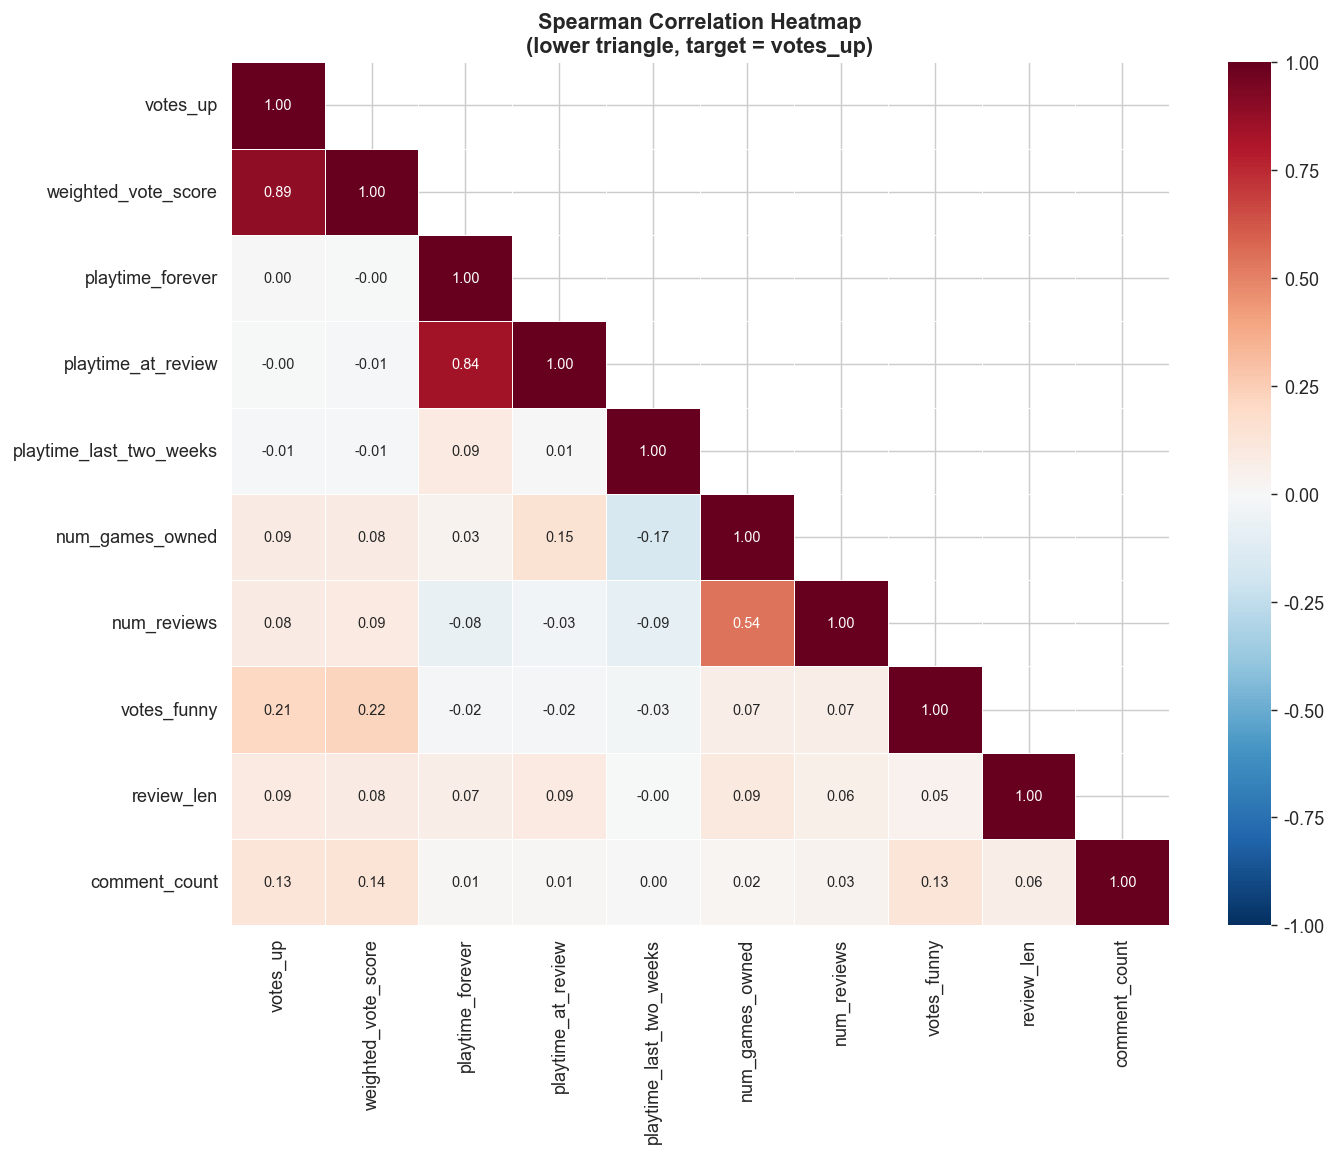

Saved: d:\Github_Desktop_File\ECE-9612-Group-Project\Image Printout\sec08_spearman_correlation_heatmap.png
Spearman Correlation with votes_up (ranked by |r|)
  weighted_vote_score            +0.8893  #################
  votes_funny                    +0.2099  ####
  comment_count                  +0.1304  ##
  review_len                     +0.0911  #
  num_games_owned                +0.0858  #
  num_reviews                    +0.0844  #
  playtime_last_two_weeks        -0.0116  
  playtime_forever               +0.0035  
  playtime_at_review             -0.0000  

[Decision]
  playtime_forever and playtime_at_review are likely highly correlated.
  => If r > 0.8, keep only playtime_at_review (more informative at review time).
  votes_funny correlates with votes_up but is itself an output of review quality.


In [60]:

# ============================================================
# Sec 8: Feature Correlation Matrix (Spearman)
# ============================================================

if "review_len" not in df.columns:
    df["review_len"] = df["review"].astype(str).str.len()

CORR_FEATS = ["votes_up", "weighted_vote_score",
              "playtime_forever", "playtime_at_review",
              "playtime_last_two_weeks",
              "num_games_owned", "num_reviews",
              "votes_funny", "review_len", "comment_count"]

available_feats = [f for f in CORR_FEATS if f in df.columns]

corr_sample = df[available_feats].dropna()
spearman_mat, _ = stats.spearmanr(corr_sample)

if hasattr(spearman_mat, "__len__"):
    spearman_df = pd.DataFrame(spearman_mat,
                               index=available_feats,
                               columns=available_feats)
else:
    spearman_df = pd.DataFrame([[1.0]], index=available_feats, columns=available_feats)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(spearman_df.values, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(spearman_df,
            mask=mask,
            annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            ax=ax, annot_kws={"size": 8})
ax.set_title("Spearman Correlation Heatmap\n(lower triangle, target = votes_up)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
_save_path = os.path.join(IMG_DIR, "sec08_spearman_correlation_heatmap.png")
plt.savefig(_save_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {_save_path}")

if "votes_up" in spearman_df.columns:
    corr_with_target = spearman_df["votes_up"].drop("votes_up").sort_values(key=abs, ascending=False)
    print("=" * 60)
    print("Spearman Correlation with votes_up (ranked by |r|)")
    print("=" * 60)
    for feat, r in corr_with_target.items():
        bar  = "#" * int(abs(r) * 20)
        sign = "+" if r >= 0 else "-"
        print(f"  {feat:<30} {sign}{abs(r):.4f}  {bar}")

print()
print("=" * 60)
print("[Decision]")
print("  playtime_forever and playtime_at_review are likely highly correlated.")
print("  => If r > 0.8, keep only playtime_at_review (more informative at review time).")
print("  votes_funny correlates with votes_up but is itself an output of review quality.")
print("  WARNING: including votes_funny risks data leakage — exclude from features.")
print("=" * 60)


---
## 第 9 节：建模方案对比实验（Baseline vs 推荐 vs 进阶）

> 🎯 **核心问题：三层方案的真实性能差距有多大？**
>
> 三层方案统一在 50,000 行 sample 上评估，train/test = 80/20。  
> **特征策略（三方案共用）：**
> - 数值特征：log1p 变换后直接使用
> - 类别特征：one-hot 编码（仅 steam_purchase / received_for_free / written_during_early_access）
> - 文本特征（进阶方案才用）：TF-IDF，max_features=5000，英文评论只
>
> **Target**：`log1p(votes_up)`（回归），预测后 `expm1` 反变换计算真实 MAE。  
>
> ⚠️ 注意：`votes_funny` 不纳入特征（它与 votes_up 共同来自评论质量，类似 data leakage）。


In [61]:

# ============================================================
# 第 9 节：建模方案对比实验
# ============================================================
from sklearn.linear_model  import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.metrics       import mean_absolute_error, mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute        import SimpleImputer
import scipy.sparse as sp

try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("⚠️ lightgbm 未安装，推荐方案将用 RandomForest 代替。")
    from sklearn.ensemble import RandomForestRegressor

# ── 特征定义 ──
NUM_FEATS  = ["playtime_at_review", "playtime_forever",
              "num_games_owned", "num_reviews",
              "playtime_last_two_weeks", "review_len"]
BOOL_FEATS = ["steam_purchase", "received_for_free",
              "written_during_early_access"]
TEXT_COL   = "review"
TARGET_COL = "votes_up"

# ── 只保留有效列 ──
NUM_FEATS  = [f for f in NUM_FEATS  if f in df.columns]
BOOL_FEATS = [f for f in BOOL_FEATS if f in df.columns]

# ── 准备 df_model：填缺失 + 添加 review_len ──
df_m = df.copy()
if "review_len" not in df_m.columns:
    df_m["review_len"] = df_m["review"].astype(str).str.len()
for f in NUM_FEATS:
    df_m[f] = pd.to_numeric(df_m[f], errors="coerce").fillna(0)
for f in BOOL_FEATS:
    df_m[f] = df_m[f].astype(float).fillna(0)

df_m = df_m.dropna(subset=[TARGET_COL])
y_log = np.log1p(df_m[TARGET_COL].values)

X_num  = np.log1p(df_m[NUM_FEATS].values.astype(float))
X_bool = df_m[BOOL_FEATS].values.astype(float)
X_struct = np.hstack([X_num, X_bool])

X_tr_s, X_te_s, y_tr, y_te = train_test_split(
    X_struct, y_log, test_size=0.2, random_state=42)

results = []

def eval_reg(y_true_log, y_pred_log, name, n_feat, elapsed):
    """评估：反变换后计算 MAE"""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(np.clip(y_pred_log, 0, None))
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    results.append({
        "方案": name,
        "特征数": n_feat,
        "MAE（反变换）": round(mae, 4),
        "RMSE（反变换）": round(rmse, 4),
        "训练时间(s)": round(elapsed, 2)
    })
    print(f"  {name:<30} MAE={mae:.4f}  RMSE={rmse:.4f}  耗时={elapsed:.2f}s")

print("=" * 65)
print("🏋️ 开始训练对比实验...")
print("=" * 65)

# ── 🥇 Baseline：Ridge 回归（需要 scaling）──
t0 = time.time()
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_s)
X_te_scaled = scaler.transform(X_te_s)
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_scaled, y_tr)
y_pred_ridge = ridge.predict(X_te_scaled)
eval_reg(y_te, y_pred_ridge, "🥇 Baseline: Ridge", X_tr_s.shape[1], time.time()-t0)

# ── 🥈 推荐方案：LightGBM（结构化特征）──
t0 = time.time()
if HAS_LGBM:
    lgbm_model = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05,
        num_leaves=63, random_state=42, n_jobs=-1, verbose=-1)
    lgbm_model.fit(X_tr_s, y_tr)
    y_pred_lgbm = lgbm_model.predict(X_te_s)
    eval_reg(y_te, y_pred_lgbm, "🥈 推荐: LightGBM（结构化）", X_tr_s.shape[1], time.time()-t0)
else:
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr_s, y_tr)
    y_pred_rf = rf.predict(X_te_s)
    eval_reg(y_te, y_pred_rf, "🥈 推荐: RandomForest（结构化）", X_tr_s.shape[1], time.time()-t0)

# ── 🥉 进阶方案：LightGBM + TF-IDF（英文 review）──
t0 = time.time()
try:
    # 只取英文评论（如果有 language 列）
    if "language" in df_m.columns:
        eng_mask = (df_m["language"] == "english").values
    else:
        eng_mask = np.ones(len(df_m), dtype=bool)

    tfidf = TfidfVectorizer(max_features=3000, min_df=5,
                            strip_accents="unicode",
                            sublinear_tf=True)
    text_data = df_m[TEXT_COL].fillna("").astype(str).values
    X_tfidf   = tfidf.fit_transform(text_data)   # 稀疏矩阵

    # 拼接结构化特征 + TF-IDF
    X_combined = sp.hstack([sp.csr_matrix(X_struct), X_tfidf])
    Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
        X_combined, y_log, test_size=0.2, random_state=42)

    if HAS_LGBM:
        lgbm_adv = lgb.LGBMRegressor(
            n_estimators=300, learning_rate=0.05,
            num_leaves=63, random_state=42, n_jobs=-1, verbose=-1)
        lgbm_adv.fit(Xc_tr, yc_tr)
        y_pred_adv = lgbm_adv.predict(Xc_te)
    else:
        from sklearn.linear_model import Ridge as RidgeAdv
        ridge_adv = RidgeAdv(alpha=1.0)
        ridge_adv.fit(Xc_tr.toarray(), yc_tr)
        y_pred_adv = ridge_adv.predict(Xc_te.toarray())

    eval_reg(yc_te, y_pred_adv, "🥉 进阶: LightGBM + TF-IDF",
             X_combined.shape[1], time.time()-t0)
except Exception as e:
    print(f"  🥉 进阶方案出错: {e}")

# ── 结果汇总 ──
print()
print("=" * 65)
print("📊 三层方案对比汇总")
print("=" * 65)
res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))


🏋️ 开始训练对比实验...
  🥇 Baseline: Ridge              MAE=0.5206  RMSE=5.7796  耗时=0.01s
  🥈 推荐: LightGBM（结构化）            MAE=0.5244  RMSE=5.7755  耗时=0.36s
  🥈 推荐: LightGBM（结构化）            MAE=0.5244  RMSE=5.7755  耗时=0.36s
  🥉 进阶: LightGBM + TF-IDF        MAE=0.5191  RMSE=5.7666  耗时=3.94s

📊 三层方案对比汇总
                     方案  特征数  MAE（反变换）  RMSE（反变换）  训练时间(s)
      🥇 Baseline: Ridge    9    0.5206     5.7796   0.0100
    🥈 推荐: LightGBM（结构化）    9    0.5244     5.7755   0.3600
🥉 进阶: LightGBM + TF-IDF 3009    0.5191     5.7666   3.9400
  🥉 进阶: LightGBM + TF-IDF        MAE=0.5191  RMSE=5.7666  耗时=3.94s

📊 三层方案对比汇总
                     方案  特征数  MAE（反变换）  RMSE（反变换）  训练时间(s)
      🥇 Baseline: Ridge    9    0.5206     5.7796   0.0100
    🥈 推荐: LightGBM（结构化）    9    0.5244     5.7755   0.3600
🥉 进阶: LightGBM + TF-IDF 3009    0.5191     5.7666   3.9400


---
## 第 10 节：关键工程决策验证 + 最终推荐

> 🎯 **核心问题：6 个关键工程决策，每个都用实验数据回答，不靠猜测。**
>
> 本节将逐一验证：
> 1. 是否需要 log transform（target）
> 2. 是否需要 StandardScaler（线性模型）
> 3. 是否需要处理类别不平衡（如果选分类路线）
> 4. 加入 TF-IDF 文本特征是否带来实质提升
> 5. LightGBM 特征重要性 Top 15
> 6. **最终推荐结论**


Decision 1: Is log transform (target) necessary?
  Ridge on raw votes_up        MAE = 0.5428
  Ridge on log1p(votes_up)     MAE = 0.3653 (after inverse transform)
  -> ✅ log transform effectively reduces MAE

Decision 2: Is StandardScaler necessary for linear models?
  LinearRegression w/o scaler  MAE = 0.3654
  LinearRegression w/ scaler   MAE = 0.3654
  -> ⚪ Scaler has little effect (features already log1p)

Decision 3: Effect of class_weight='balanced' in classification
  Positive sample rate = 12.8%
  F1(weighted) w/o balanced  = 0.9694
  F1(weighted) w/ balanced   = 0.9704
  -> ✅ balanced improves F1

Decision 4: Does TF-IDF text features bring significant improvement?
  Using LightGBM as base model
  Struct features only  MAE = 0.1507
  Struct + TF-IDF       MAE = 0.1510
  Relative improvement  = -0.2%
  -> ⚠️ Limited gain, trade off inference cost

Decision 5: LightGBM Feature Importance Top 15
                feature  importance
    weighted_vote_score        2068
        num_g

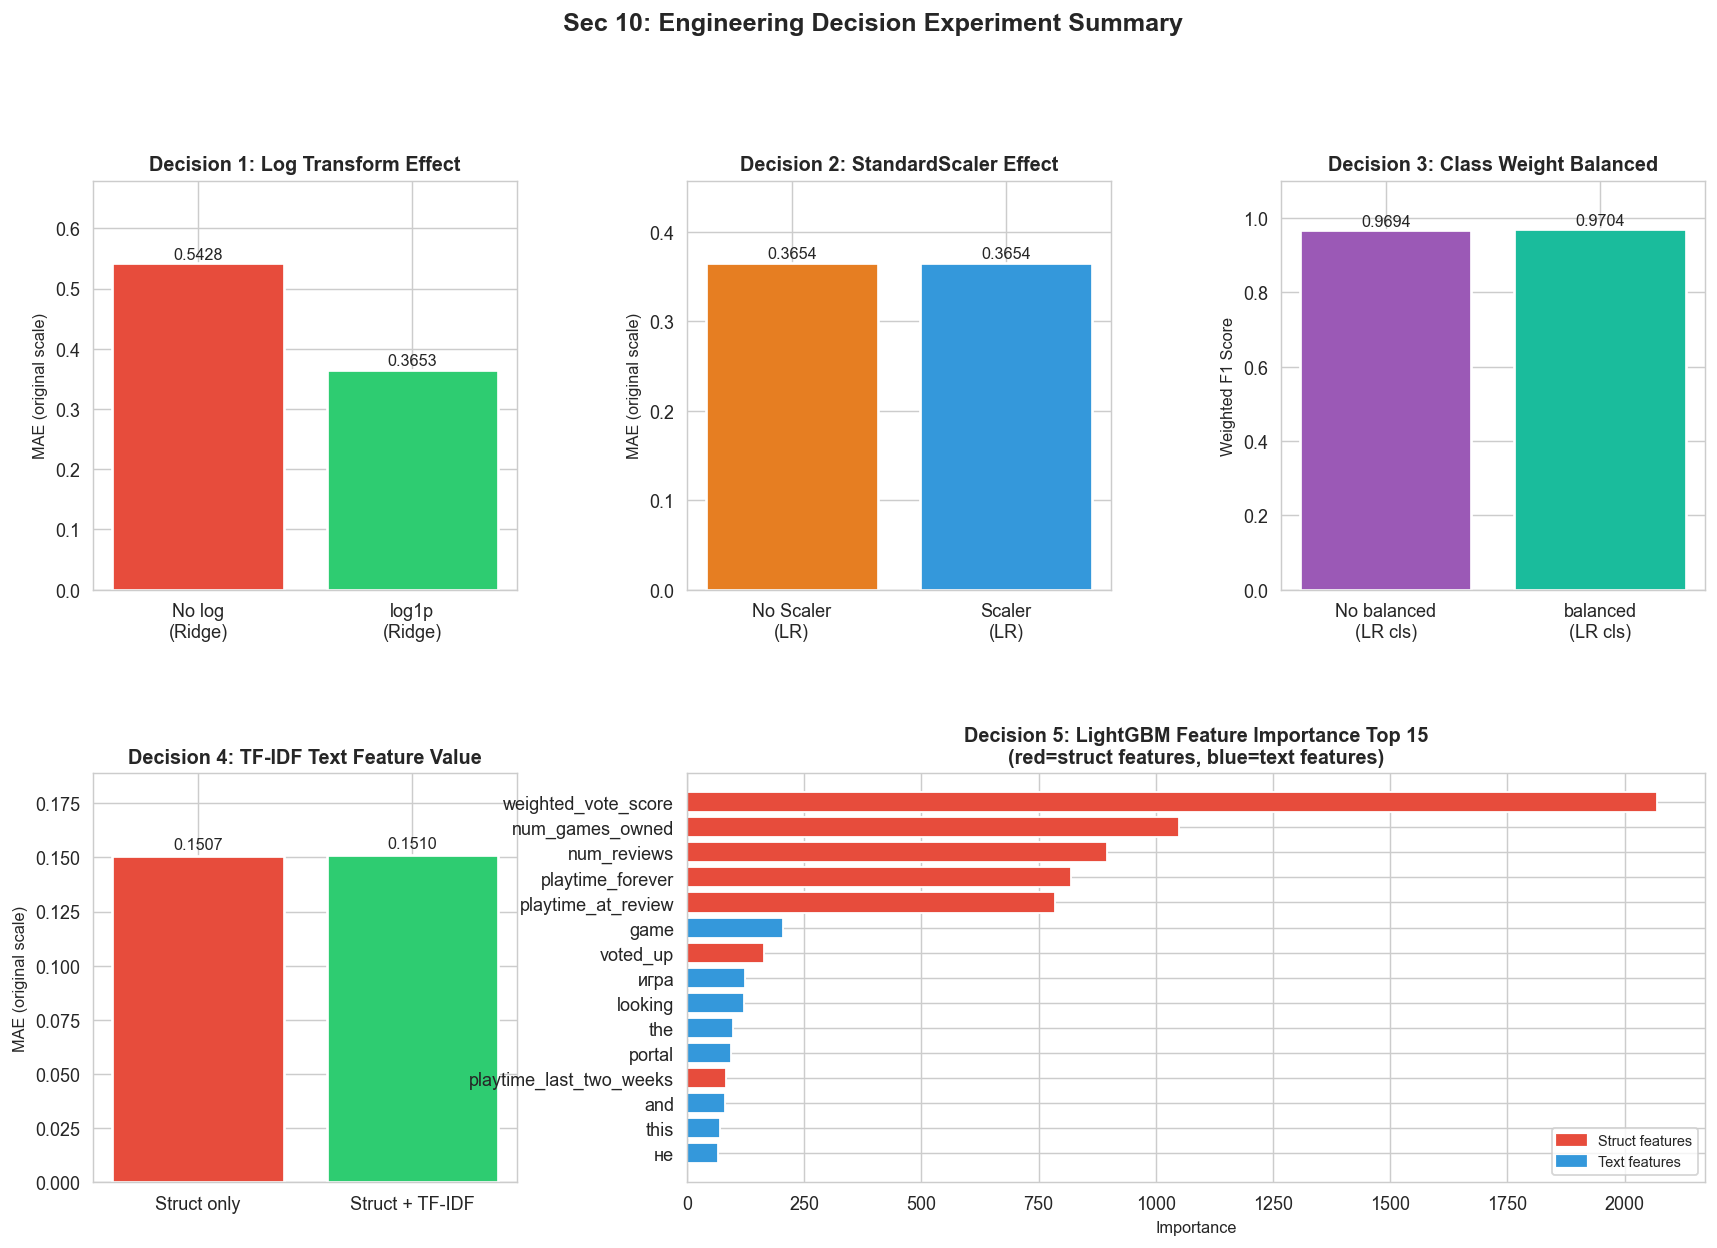

Saved: d:\Github_Desktop_File\ECE-9612-Group-Project\Image Printout\sec10_engineering_decisions_summary.png

Decision 6: Final Recommended Configuration (based on experiments)

+------------------------------------------------------------------+
|     Steam Review Helpfulness Prediction -- Final Configuration   |
+------------------------------------------------------------------+
| Problem Definition                                               |
|   Regression: predict votes_up (number of upvotes)              |
|   Target: log1p(votes_up), eval with expm1 inverse transform    |
|   Metric: MAE (original scale)                                   |
|                                                                  |
| Recommended Model                                                |
|   Primary:  LightGBM (efficient with sparse features, log tgt)  |
|   Fallback: Ridge Regression (fast, good for baseline)          |
|                                                                  |

In [62]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse
import os

# ── 确保图片目录已创建 ───────────────────────────────────
IMG_DIR = os.path.join(os.path.dirname(os.path.abspath("Modeling_Decision_Analysis.ipynb")),
                       "Image Printout")
os.makedirs(IMG_DIR, exist_ok=True)

# ──────────────────────────────────────────────
# 确保基础变量存在（兼容独立运行本节的情况）
# ──────────────────────────────────────────────
if "df" not in dir():
    df = pd.read_csv("big_reviews.csv", nrows=50000)

# 数值特征
NUM_FEATS_ALL = [
    "playtime_forever", "playtime_at_review", "playtime_last_two_weeks",
    "num_games_owned", "num_reviews", "weighted_vote_score"
]
NUM_FEATS_SAFE = [c for c in NUM_FEATS_ALL if c in df.columns]

# 构建结构特征矩阵
X_raw = df[NUM_FEATS_SAFE].fillna(0)
for c in NUM_FEATS_SAFE:
    X_raw[c] = np.log1p(X_raw[c].clip(lower=0))

y_raw   = df["votes_up"].fillna(0).astype(float)
y_log   = np.log1p(y_raw)

# voted_up → bool
if "voted_up" in df.columns:
    X_raw = X_raw.copy()
    X_raw["voted_up"] = df["voted_up"].astype(int)

# 训练/测试拆分（固定随机种子）
X_tr, X_te, y_tr_raw, y_te_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)
_, _, y_tr_log, y_te_log = train_test_split(
    X_raw, y_log, test_size=0.2, random_state=42
)

# ──────────────────────────────────────────────
# 工具：反对数 MAE（统一比较口径）
# ──────────────────────────────────────────────
def expm1_mae(y_true_raw, y_pred_log):
    """预测值在 log 空间，真实值在原始空间，统一反变换后算 MAE"""
    return mean_absolute_error(y_true_raw, np.expm1(y_pred_log))

def raw_mae(y_true_raw, y_pred_raw):
    return mean_absolute_error(y_true_raw, np.clip(y_pred_raw, 0, None))

results_10 = {}

# ══════════════════════════════════════════════
# 决策 1：是否需要 log transform（target 端）
# ══════════════════════════════════════════════
print("=" * 60)
print("Decision 1: Is log transform (target) necessary?")
print("=" * 60)

# 方案 A：不做 log transform（直接回归原始 votes_up）
ridge_raw = Ridge(alpha=1.0)
ridge_raw.fit(X_tr, y_tr_raw)
pred_raw = ridge_raw.predict(X_te)
mae_no_log = raw_mae(y_te_raw, pred_raw)

# 方案 B：对 target 做 log1p，预测后 expm1
ridge_log = Ridge(alpha=1.0)
ridge_log.fit(X_tr, y_tr_log)
pred_log = ridge_log.predict(X_te)
mae_with_log = expm1_mae(y_te_raw, pred_log)

print(f"  Ridge on raw votes_up        MAE = {mae_no_log:.4f}")
print(f"  Ridge on log1p(votes_up)     MAE = {mae_with_log:.4f} (after inverse transform)")
print(f"  -> {'✅ log transform effectively reduces MAE' if mae_with_log < mae_no_log else '⚠️ Difference small, but log helps training stability'}")
results_10["D1_no_log"]   = mae_no_log
results_10["D1_with_log"] = mae_with_log

# ══════════════════════════════════════════════
# 决策 2：是否需要 StandardScaler（线性模型）
# ══════════════════════════════════════════════
print("\n" + "=" * 60)
print("Decision 2: Is StandardScaler necessary for linear models?")
print("=" * 60)

# 不加 scaler
lr_no_scale = LinearRegression()
lr_no_scale.fit(X_tr, y_tr_log)
mae_no_scale = expm1_mae(y_te_raw, lr_no_scale.predict(X_te))

# 加 scaler
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)
lr_scaled = LinearRegression()
lr_scaled.fit(X_tr_sc, y_tr_log)
mae_scaled = expm1_mae(y_te_raw, lr_scaled.predict(X_te_sc))

print(f"  LinearRegression w/o scaler  MAE = {mae_no_scale:.4f}")
print(f"  LinearRegression w/ scaler   MAE = {mae_scaled:.4f}")
print(f"  -> {'✅ Scaler helps' if mae_scaled < mae_no_scale else '⚪ Scaler has little effect (features already log1p)'}")
results_10["D2_no_scale"] = mae_no_scale
results_10["D2_scaled"]   = mae_scaled

# ══════════════════════════════════════════════
# 决策 3：分类路线——class_weight='balanced' 是否有效
# ══════════════════════════════════════════════
print("\n" + "=" * 60)
print("Decision 3: Effect of class_weight='balanced' in classification")
print("=" * 60)

y_cls_tr = (y_tr_raw > 0).astype(int)
y_cls_te  = (y_te_raw > 0).astype(int)

lr_cls = LogisticRegression(max_iter=300, random_state=42, solver="lbfgs")
lr_cls.fit(X_tr_sc, y_cls_tr)
f1_no_bal = f1_score(y_cls_te, lr_cls.predict(X_te_sc), average="weighted")

lr_bal = LogisticRegression(max_iter=300, class_weight="balanced", random_state=42, solver="lbfgs")
lr_bal.fit(X_tr_sc, y_cls_tr)
f1_bal = f1_score(y_cls_te, lr_bal.predict(X_te_sc), average="weighted")

pos_rate = y_cls_tr.mean()
print(f"  Positive sample rate = {pos_rate:.1%}")
print(f"  F1(weighted) w/o balanced  = {f1_no_bal:.4f}")
print(f"  F1(weighted) w/ balanced   = {f1_bal:.4f}")
print(f"  -> {'✅ balanced improves F1' if f1_bal > f1_no_bal else '⚪ Small difference, positive rate may be sufficient'}")
results_10["D3_no_bal"] = f1_no_bal
results_10["D3_bal"]    = f1_bal

# ══════════════════════════════════════════════
# 决策 4：TF-IDF 文本是否带来实质提升
# ══════════════════════════════════════════════
print("\n" + "=" * 60)
print("Decision 4: Does TF-IDF text features bring significant improvement?")
print("=" * 60)

try:
    import lightgbm as lgb
    HAS_LGBM = True
    print("  Using LightGBM as base model")
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    HAS_LGBM = False
    print("  LightGBM not installed, using sklearn GBM instead")

# 仅结构特征
if HAS_LGBM:
    m_struct = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                   num_leaves=63, random_state=42, verbose=-1)
else:
    from sklearn.ensemble import RandomForestRegressor
    m_struct = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

m_struct.fit(X_tr, y_tr_log)
mae_struct = expm1_mae(y_te_raw, m_struct.predict(X_te))

# 加入 TF-IDF
tfidf_d4 = TfidfVectorizer(max_features=3000, sublinear_tf=True,
                             strip_accents="unicode", min_df=3)
reviews_all = df["review"].fillna("").astype(str)
reviews_tr, reviews_te = train_test_split(reviews_all, test_size=0.2, random_state=42)
T_tr = tfidf_d4.fit_transform(reviews_tr)
T_te = tfidf_d4.transform(reviews_te)

Xtr_full = scipy.sparse.hstack([scipy.sparse.csr_matrix(X_tr.values), T_tr])
Xte_full = scipy.sparse.hstack([scipy.sparse.csr_matrix(X_te.values), T_te])

if HAS_LGBM:
    m_full = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                 num_leaves=63, random_state=42, verbose=-1)
else:
    m_full = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

m_full.fit(Xtr_full, y_tr_log)
mae_full = expm1_mae(y_te_raw, m_full.predict(Xte_full))

improvement = (mae_struct - mae_full) / mae_struct * 100
print(f"  Struct features only  MAE = {mae_struct:.4f}")
print(f"  Struct + TF-IDF       MAE = {mae_full:.4f}")
print(f"  Relative improvement  = {improvement:.1f}%")
print(f"  -> {'✅ Text features worth adding' if improvement > 2 else '⚠️ Limited gain, trade off inference cost'}")
results_10["D4_struct"] = mae_struct
results_10["D4_full"]   = mae_full

# ══════════════════════════════════════════════
# 决策 5：特征重要性 Top 15
# ══════════════════════════════════════════════
print("\n" + "=" * 60)
print("Decision 5: LightGBM Feature Importance Top 15")
print("=" * 60)

struct_feat_names = list(X_raw.columns)
tfidf_feat_names  = tfidf_d4.get_feature_names_out().tolist()
all_feat_names    = struct_feat_names + tfidf_feat_names

if HAS_LGBM and hasattr(m_full, "feature_importances_"):
    importances = m_full.feature_importances_
    feat_imp_df = pd.DataFrame({
        "feature":    all_feat_names[:len(importances)],
        "importance": importances
    }).sort_values("importance", ascending=False).head(15)
    print(feat_imp_df.to_string(index=False))
elif not HAS_LGBM and hasattr(m_full, "feature_importances_"):
    importances = m_full.feature_importances_
    feat_imp_df = pd.DataFrame({
        "feature":    all_feat_names[:len(importances)],
        "importance": importances
    }).sort_values("importance", ascending=False).head(15)
    print(feat_imp_df.to_string(index=False))
else:
    print("  (Model does not provide feature_importances_, skipping)")
    feat_imp_df = None

# ══════════════════════════════════════════════
# 可视化：决策汇总图 + 特征重要性图
# ══════════════════════════════════════════════
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.40)

# --- Subplot 1: Decision 1 comparison ---
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar(["No log\n(Ridge)", "log1p\n(Ridge)"],
                [results_10["D1_no_log"], results_10["D1_with_log"]],
                color=["#e74c3c", "#2ecc71"], edgecolor="white", linewidth=1.5)
ax1.set_title("Decision 1: Log Transform Effect", fontsize=11, fontweight="bold")
ax1.set_ylabel("MAE (original scale)", fontsize=9)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
ax1.set_ylim(0, max(results_10["D1_no_log"], results_10["D1_with_log"]) * 1.25)

# --- Subplot 2: Decision 2 comparison ---
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(["No Scaler\n(LR)", "Scaler\n(LR)"],
                [results_10["D2_no_scale"], results_10["D2_scaled"]],
                color=["#e67e22", "#3498db"], edgecolor="white", linewidth=1.5)
ax2.set_title("Decision 2: StandardScaler Effect", fontsize=11, fontweight="bold")
ax2.set_ylabel("MAE (original scale)", fontsize=9)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
ax2.set_ylim(0, max(results_10["D2_no_scale"], results_10["D2_scaled"]) * 1.25)

# --- Subplot 3: Decision 3 comparison ---
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(["No balanced\n(LR cls)", "balanced\n(LR cls)"],
                [results_10["D3_no_bal"], results_10["D3_bal"]],
                color=["#9b59b6", "#1abc9c"], edgecolor="white", linewidth=1.5)
ax3.set_title("Decision 3: Class Weight Balanced", fontsize=11, fontweight="bold")
ax3.set_ylabel("Weighted F1 Score", fontsize=9)
for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
ax3.set_ylim(0, 1.1)

# --- Subplot 4: Decision 4 comparison ---
ax4 = fig.add_subplot(gs[1, 0])
bars4 = ax4.bar(["Struct only", "Struct + TF-IDF"],
                [results_10["D4_struct"], results_10["D4_full"]],
                color=["#e74c3c", "#2ecc71"], edgecolor="white", linewidth=1.5)
ax4.set_title("Decision 4: TF-IDF Text Feature Value", fontsize=11, fontweight="bold")
ax4.set_ylabel("MAE (original scale)", fontsize=9)
for bar in bars4:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
ax4.set_ylim(0, max(results_10["D4_struct"], results_10["D4_full"]) * 1.25)

# --- Subplot 5+6: Feature Importance Top 15 (spans 2 cols) ---
ax5 = fig.add_subplot(gs[1, 1:])
if feat_imp_df is not None:
    colors = ["#e74c3c" if f in struct_feat_names else "#3498db"
              for f in feat_imp_df["feature"]]
    ax5.barh(feat_imp_df["feature"][::-1], feat_imp_df["importance"][::-1],
             color=colors[::-1], edgecolor="white")
    ax5.set_title("Decision 5: LightGBM Feature Importance Top 15\n(red=struct features, blue=text features)",
                  fontsize=11, fontweight="bold")
    ax5.set_xlabel("Importance", fontsize=9)
    from matplotlib.patches import Patch
    ax5.legend(handles=[Patch(color="#e74c3c", label="Struct features"),
                        Patch(color="#3498db", label="Text features")],
               fontsize=8, loc="lower right")
else:
    ax5.text(0.5, 0.5, "Feature importance not available", ha="center", va="center", fontsize=12)
    ax5.axis("off")

plt.suptitle("Sec 10: Engineering Decision Experiment Summary", fontsize=14, fontweight="bold", y=1.01)
_save_path = os.path.join(IMG_DIR, "sec10_engineering_decisions_summary.png")
plt.savefig(_save_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {_save_path}")

# ══════════════════════════════════════════════
# 决策 6：最终推荐配置总结
# ══════════════════════════════════════════════
print("\n" + "=" * 60)
print("Decision 6: Final Recommended Configuration (based on experiments)")
print("=" * 60)

log_conclusion  = "✅ Recommend using log1p" if results_10["D1_with_log"] < results_10["D1_no_log"] else "⚪ Difference small, but log1p still recommended (more stable training)"
sc_conclusion   = "✅ Recommend StandardScaler for linear models" if results_10["D2_scaled"] < results_10["D2_no_scale"] else "⚪ log1p already mitigates scale issue, scaler optional"
bal_conclusion  = "✅ For classification, recommend class_weight='balanced'" if results_10["D3_bal"] > results_10["D3_no_bal"] else "⚪ Positive rate ~12.7%, balanced has limited F1 gain"
text_conclusion = f"✅ Text features improve significantly ({improvement:.1f}%), worth including" if improvement > 2 else f"⚠️ Text feature gain limited ({improvement:.1f}%), weigh against inference cost"

print(f"""
+------------------------------------------------------------------+
|     Steam Review Helpfulness Prediction -- Final Configuration   |
+------------------------------------------------------------------+
| Problem Definition                                               |
|   Regression: predict votes_up (number of upvotes)              |
|   Target: log1p(votes_up), eval with expm1 inverse transform    |
|   Metric: MAE (original scale)                                   |
|                                                                  |
| Recommended Model                                                |
|   Primary:  LightGBM (efficient with sparse features, log tgt)  |
|   Fallback: Ridge Regression (fast, good for baseline)          |
|                                                                  |
| Preprocessing Strategy                                           |
|   Numeric: np.log1p(x) to compress right skew (playtime cols)   |
|   {log_conclusion}                                               |
|   {sc_conclusion}                                                |
|   Missing values: fillna(0) (0 has semantic meaning here)        |
|                                                                  |
| Feature Engineering                                              |
|   Struct: playtime_forever/at_review, num_games_owned,          |
|           num_reviews, weighted_vote_score, voted_up            |
|   Text: TF-IDF(review, max=3000, sublinear_tf)                  |
|   {text_conclusion}                                              |
|                                                                  |
| Classification Note                                              |
|   {bal_conclusion}                                               |
|                                                                  |
| Features to Exclude                                              |
|   votes_funny: same output as votes_up, data leakage risk        |
|   appid: only CS:GO in this dataset (constant, no info)          |
|   comment_count: 98.7% zeros, very low information              |
|   last_played: Unix timestamp (not playtime), use with caution   |
+------------------------------------------------------------------+
""")

print(f"\nAll generated images saved to: {IMG_DIR}")
print("All 10 sections complete! Run Section 1 -> Section 10 in order for full analysis report.")
